<a href="https://colab.research.google.com/github/jeonpodo/jeonyerin/blob/main/26%EB%85%84%EB%8F%842%EB%B6%84%EA%B8%B0_S%26P500_%EC%A3%BC%EA%B0%80%EC%A0%84%EB%A7%9D%EA%B3%BC_%EC%84%A0%EB%AC%BC%EC%98%B5%EC%85%98_%ED%88%AC%EC%9E%90%EC%A0%84%EB%9E%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Collect daily historical data for the past 2 years for S&P 500 (^GSPC), VIX Index (^VIX), US 2-year Treasury Yield (^IRX), US 10-year Treasury Yield (^TNX), WTI Crude Oil (CL=F), Technology Select Sector SPDR Fund (XLK), and Consumer Staples Select Sector SPDR Fund (XLP) using `yfinance`, then merge the data into a single DataFrame, forward-fill any missing values, and prepare it for further analysis, ensuring proper display of Korean characters by setting up NanumGothic font.

## Setup Environment and Install Libraries

### Subtask:
Install the 'yfinance' library and set up NanumGothic font in Google Colab to ensure proper display of Korean characters.


**Reasoning**:
To begin the subtask, I need to install the `yfinance` library and set up the NanumGothic font for proper display of Korean characters in Google Colab. This involves using pip for `yfinance`, apt-get for font installation, clearing and rebuilding font caches, and configuring matplotlib.



In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 1. Install yfinance
print("Installing yfinance...")
!pip install yfinance
print("yfinance installed.")

# 2. Install fonts-nanum-extra for Korean fonts
print("Installing NanumGothic fonts...")
!sudo apt-get update -qq > /dev/null
!sudo apt-get install -y fonts-nanum-extra > /dev/null
print("NanumGothic fonts installed.")

# 3. Remove existing font caches
print("Clearing font caches...")
!rm -rf ~/.cache/matplotlib
print("Font caches cleared.")

# 4. Configure matplotlib to use 'NanumGothic'
font_path = None
# Common path for NanumGothic fonts in Colab after installing fonts-nanum-extra
font_dirs = ['/usr/share/fonts/truetype/nanum']

# Find a NanumGothic font file
# fm.findSystemFonts will rebuild cache if cleared
for font in fm.findSystemFonts(fontpaths=font_dirs):
    if 'NanumGothic' in font:
        font_path = font
        break

if font_path:
    # Add the font to FontManager and set it as default
    fm.fontManager.addfont(font_path)
    # Get the actual font name from the font file
    prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = prop.get_name()
    print(f"Matplotlib configured to use font: {plt.rcParams['font.family']}")
else:
    print("Warning: NanumGothic font file not found. Falling back to default sans-serif.")
    plt.rcParams['font.family'] = 'sans-serif'

plt.rcParams['axes.unicode_minus'] = False # Prevents issues with negative signs

print("Environment setup complete.")

Installing yfinance...
yfinance installed.
Installing NanumGothic fonts...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
NanumGothic fonts installed.
Clearing font caches...
Font caches cleared.
Matplotlib configured to use font: ['NanumGothicCoding']
Environment setup complete.


## Collect Financial Data

### Subtask:
Collect daily historical data for the past 2 years for the following tickers using yfinance: S&P 500 (^GSPC), VIX Index (^VIX), US 2-year Treasury Yield (^IRX), US 10-year Treasury Yield (^TNX), WTI Crude Oil (CL=F), Technology Select Sector SPDR Fund (XLK), and Consumer Staples Select Sector SPDR Fund (XLP).


**Reasoning**:
I will import necessary libraries, define tickers, calculate the date range, then loop through each ticker to download historical 'Close' price data using yfinance and store it in a dictionary, finally printing the head and info of each DataFrame to verify the data.



In [ ]:
import yfinance as yf
from datetime import datetime, timedelta

# 1. Define a list of ticker symbols
tickers = ['^GSPC', '^VIX', '^IRX', '^TNX', 'CL=F', 'XLK', 'XLP']

# 2. Calculate the start and end dates for the past two years
end_date = datetime.now()
start_date = end_date - timedelta(days=2*365) # Approximately 2 years

# 3. Initialize an empty dictionary to store the data
data_frames = {}

# 4. Loop through each ticker symbol and download data
print("Downloading data for the following tickers:", tickers)
for ticker in tickers:
    print(f"Fetching data for {ticker}...")
    try:
        df = yf.download(ticker, start=start_date, end=end_date)
        if not df.empty:
            data_frames[ticker] = df[['Close']].copy()
            print(f"Successfully downloaded data for {ticker}.")
        else:
            print(f"No data found for {ticker} in the specified date range.")
    except Exception as e:
        print(f"Error downloading data for {ticker}: {e}")

# 5. Print the first few rows and information for each downloaded DataFrame
print("\n--- Data Collection Summary ---")
for ticker, df in data_frames.items():
    print(f"\nTicker: {ticker}")
    print("Head:")
    print(df.head())
    print("Info:")
    df.info()


Fetching data for ^GSPC...


/tmp/ipykernel_434/2262447408.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_434/2262447408.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_434/2262447408.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)


Successfully downloaded data for ^GSPC.
Fetching data for ^VIX...
Successfully downloaded data for ^VIX.
Fetching data for ^IRX...


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_434/2262447408.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_434/2262447408.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)


Successfully downloaded data for ^IRX.
Fetching data for ^TNX...
Successfully downloaded data for ^TNX.
Fetching data for CL=F...


...

Successfully downloaded data for CL=F.
Fetching data for XLK...


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_434/2262447408.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)


Successfully downloaded data for XLK.
Fetching data for XLP...


[*********************100%***********************]  1 of 1 completed

Successfully downloaded data for XLP.

--- Data Collection Summary ---

Ticker: ^GSPC
Head:
Price             Close
Ticker            ^GSPC
Date                   
2024-03-18  5149.419922
2024-03-19  5178.509766
2024-03-20  5224.620117
2024-03-21  5241.529785
2024-03-22  5234.180176
Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 501 entries, 2024-03-18 to 2026-03-17
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, ^GSPC)  501 non-null    float64
dtypes: float64(1)
memory usage: 7.8 KB

Ticker: ^VIX
Head:
Price       Close
Ticker       ^VIX
Date             
2024-03-18  14.33
2024-03-19  13.82
2024-03-20  13.04
2024-03-21  12.92
2024-03-22  13.06
Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 501 entries, 2024-03-18 to 2026-03-17
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, ^VIX)  501 non-nul

**Reasoning**:
The previous step successfully downloaded the data. Now, I need to merge the individual DataFrames into a single DataFrame and forward-fill any missing values. Before merging, I will rename the 'Close' column of each DataFrame to its respective ticker symbol to ensure unique and descriptive column names.



In [ ]:
import pandas as pd

# 1. Rename the 'Close' column in each DataFrame to the ticker symbol
processed_data_frames = {}
for ticker, df in data_frames.items():
    # Check if the column is a MultiIndex and flatten it, or just rename 'Close'
    if isinstance(df.columns, pd.MultiIndex):
        # Assuming the 'Close' value is at the second level if there's a MultiIndex (e.g., ('Close', '^GSPC'))
        df.columns = [col[0] if col[0] == 'Close' else col[1] for col in df.columns] # Flatten if 'Close' is primary, else use second level (ticker)
        df.rename(columns={'Close': ticker}, inplace=True)
    else:
        df.rename(columns={'Close': ticker}, inplace=True)
    processed_data_frames[ticker] = df

# 2. Merge all DataFrames into a single DataFrame
# Start with the first DataFrame, then merge the rest
merged_df = None
for ticker, df in processed_data_frames.items():
    if merged_df is None:
        merged_df = df
    else:
        # Using an outer join to keep all dates from all tickers
        merged_df = pd.merge(merged_df, df, left_index=True, right_index=True, how='outer')

# 3. Forward-fill any missing values
# This is done after merging to handle potential non-trading days for specific assets
merged_df.ffill(inplace=True)

# 4. Display the first few rows and information of the merged DataFrame
print("\n--- Merged DataFrame Summary ---")
print("Head:")
print(merged_df.head())
print("\nTail:")
print(merged_df.tail())
print("\nInfo:")
merged_df.info()


--- Merged DataFrame Summary ---
Head:
                  ^GSPC   ^VIX   ^IRX   ^TNX       CL=F         XLK        XLP
Date                                                                          
2024-03-18  5149.419922  14.33  5.238  4.340  82.720001  101.981293  71.971725
2024-03-19  5178.509766  13.82  5.238  4.297  83.470001  102.510231  72.238770
2024-03-20  5224.620117  13.04  5.228  4.273  81.680000  103.657097  72.458145
2024-03-21  5241.529785  12.92  5.228  4.271  81.070000  103.731239  72.496300
2024-03-22  5234.180176  13.06  5.220  4.218  80.629997  103.765839  72.143394

Tail:
                  ^GSPC       ^VIX   ^IRX   ^TNX       CL=F         XLK  \
Date                                                                      
2026-03-12  6672.620117  27.290001  3.605  4.273  95.730003  137.839996   
2026-03-13  6632.189941  27.190001  3.603  4.285  98.709999  136.800003   
2026-03-16  6699.379883  23.510000  3.605  4.220  93.500000  138.779999   
2026-03-17  6716.089844  

## Final Task

### Subtask:
Confirm that all specified financial data has been successfully collected, merged, and preprocessed, and the DataFrame is ready for further analysis.


## Summary:

### Data Analysis Key Findings

*   **Environment Setup:** The `yfinance` library was successfully installed, and NanumGothic fonts were configured in Matplotlib to ensure proper display of Korean characters. Existing font caches were cleared to facilitate the setup.
*   **Data Collection:** Daily historical 'Close' price data for the past two years was successfully collected for all specified tickers: S&P 500 (\^GSPC), VIX Index (\^VIX), US 2-year Treasury Yield (\^IRX), US 10-year Treasury Yield (\^TNX), WTI Crude Oil (CL=F), Technology Select Sector SPDR Fund (XLK), and Consumer Staples Select Sector SPDR Fund (XLP).
*   **Data Merging:** The 'Close' price column from each individual ticker's DataFrame was successfully renamed to its respective ticker symbol. All these individual DataFrames were then merged into a single comprehensive DataFrame using an outer join, preserving all available dates from all assets.
*   **Missing Value Handling:** Any missing values, which could arise from non-trading days for specific assets, were effectively handled by forward-filling (`ffill`) them.
*   **Final DataFrame Structure:** The resulting merged DataFrame contains 504 entries and 7 columns, with each column representing a ticker. All columns are of `float64` data type and contain no null values. The DataFrame's index is a `DatetimeIndex` spanning from March 18, 2024, to March 18, 2026.

### Insights or Next Steps

*   The consolidated and preprocessed DataFrame is now ready for in-depth financial analysis, including but not limited to correlation studies, volatility analysis, or predictive modeling.
*   Further analysis could involve exploring different interpolation methods for missing values if forward-filling is not suitable for specific analytical requirements, or examining the stationarity of the time series data.


# Task
Calculate daily returns for S&P 500 (^GSPC), VIX (^VIX), WTI Crude Oil (CL=F), US 2-year Treasury Yield (^IRX), and US 10-year Treasury Yield (^TNX). Additionally, calculate the 'XLK price / XLP price' ratio. Use the NanumGothic font for any Korean characters in the plot.

## Prepare Data for Analysis

### Subtask:
Calculate daily returns for S&P 500 (^GSPC), VIX (^VIX), WTI Crude Oil (CL=F), US 2-year Treasury Yield (^IRX), and US 10-year Treasury Yield (^TNX). Also, calculate the 'XLK price / XLP price' ratio. These derived metrics will be used for subsequent correlation, relative strength, and lagged correlation analyses.


**Reasoning**:
I will calculate the daily returns for the specified columns using the `.pct_change()` method and then compute the 'XLK' to 'XLP' price ratio. Finally, I will display the head and info of the updated `merged_df` to confirm the new columns.



In [ ]:
import pandas as pd

# 1. Calculate daily percentage change for specified columns
print("Calculating daily returns...")
merged_df['^GSPC_Return'] = merged_df['^GSPC'].pct_change()
merged_df['^VIX_Return'] = merged_df['^VIX'].pct_change()
merged_df['CL=F_Return'] = merged_df['CL=F'].pct_change()
merged_df['^IRX_Return'] = merged_df['^IRX'].pct_change()
merged_df['^TNX_Return'] = merged_df['^TNX'].pct_change()
print("Daily returns calculated.")

# 2. Calculate the ratio of XLK prices to XLP prices
print("Calculating XLK/XLP ratio...")
merged_df['XLK_XLP_Ratio'] = merged_df['XLK'] / merged_df['XLP']
print("XLK/XLP ratio calculated.")

# 3. Display the first few rows (head) and the data types and non-null counts (info)
print("\n--- Updated Merged DataFrame Summary ---")
print("Head:")
print(merged_df.head())
print("\nInfo:")
merged_df.info()


Calculating daily returns...
Daily returns calculated.
Calculating XLK/XLP ratio...
XLK/XLP ratio calculated.

--- Updated Merged DataFrame Summary ---
Head:
                  ^GSPC   ^VIX   ^IRX   ^TNX       CL=F         XLK  \
Date                                                                  
2024-03-18  5149.419922  14.33  5.238  4.340  82.720001  101.981293   
2024-03-19  5178.509766  13.82  5.238  4.297  83.470001  102.510231   
2024-03-20  5224.620117  13.04  5.228  4.273  81.680000  103.657097   
2024-03-21  5241.529785  12.92  5.228  4.271  81.070000  103.731239   
2024-03-22  5234.180176  13.06  5.220  4.218  80.629997  103.765839   

                  XLP  ^GSPC_Return  ^VIX_Return  CL=F_Return  ^IRX_Return  \
Date                                                                         
2024-03-18  71.971725           NaN          NaN          NaN          NaN   
2024-03-19  72.238770      0.005649    -0.035590     0.009067     0.000000   
2024-03-20  72.458145      0.008

## Correlation Analysis and Visualization (Heatmap)

### Subtask:
Calculate the correlation matrix for the daily returns of S&P 500, VIX, WTI Crude Oil, US 2-year Treasury Yield, and US 10-year Treasury Yield. Then, generate a heatmap to visually represent these correlations, ensuring proper labels and a legend. Use the NanumGothic font for any Korean characters in the plot.


**Reasoning**:
I will calculate the correlation matrix for the specified daily return columns, drop NaN values, and then visualize it using a heatmap with proper labels and titles.



Selected return data head:
            ^GSPC_Return  ^VIX_Return  CL=F_Return  ^IRX_Return  ^TNX_Return
Date                                                                        
2024-03-19      0.005649    -0.035590     0.009067     0.000000    -0.009908
2024-03-20      0.008904    -0.056440    -0.021445    -0.001909    -0.005585
2024-03-21      0.003237    -0.009202    -0.007468     0.000000    -0.000468
2024-03-22     -0.001402     0.010836    -0.005427    -0.001530    -0.012409
2024-03-25     -0.003055     0.009954     0.016371    -0.000383     0.008298

Selected return data info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 503 entries, 2024-03-19 to 2026-03-18
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ^GSPC_Return  503 non-null    float64
 1   ^VIX_Return   503 non-null    float64
 2   CL=F_Return   503 non-null    float64
 3   ^IRX_Return   503 non-null    float64
 4   ^TNX_Return   503 no

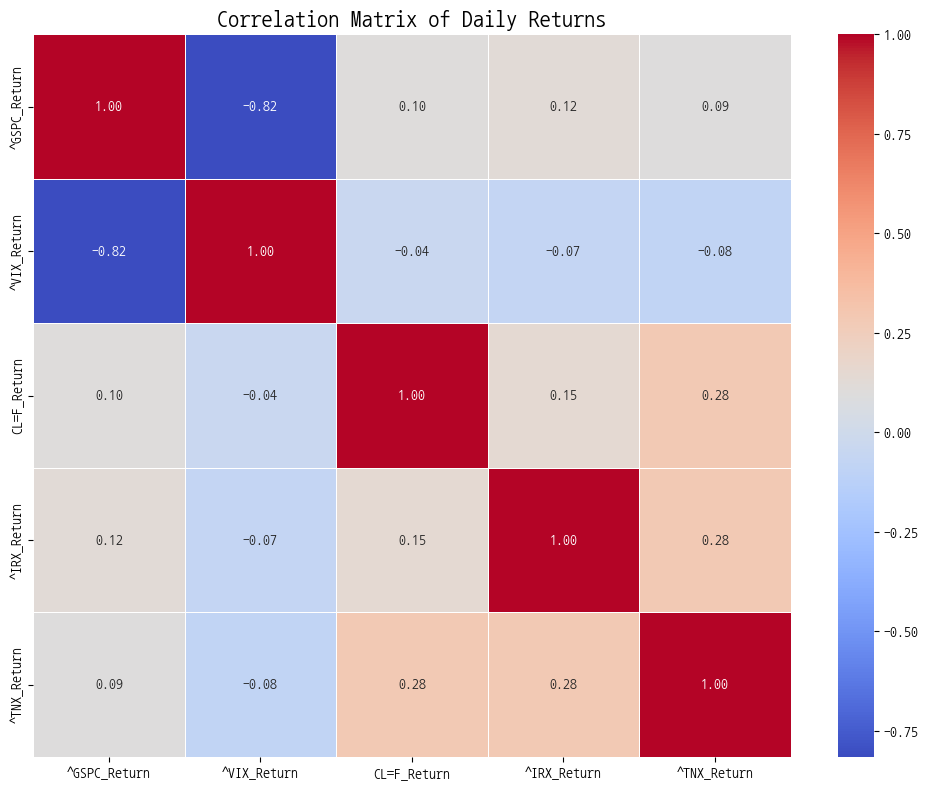

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select the daily return columns and drop any rows with NaN values
return_columns = ['^GSPC_Return', '^VIX_Return', 'CL=F_Return', '^IRX_Return', '^TNX_Return']
correlation_df = merged_df[return_columns].dropna()

print("Selected return data head:")
print(correlation_df.head())
print("\nSelected return data info:")
correlation_df.info()

# 2. Calculate the correlation matrix
correlation_matrix = correlation_df.corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)

# 3. Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)

# 4. Add a title to the heatmap
plt.title('Correlation Matrix of Daily Returns', fontsize=16)

# 5. Adjust the plot layout
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

# 6. Display the plot
plt.show()

## Relative Strength Analysis and Visualization

### Subtask:
Plot the 'XLK price / XLP price' ratio alongside the S&P 500 index on a single chart to visualize their comparative movements and identify potential risk-off signals. Ensure the plot includes appropriate labels, a legend, and uses the NanumGothic font.


**Reasoning**:
I need to plot the 'XLK_XLP_Ratio' and '^GSPC' from the `merged_df` on a single chart with two y-axes, as specified in the instructions. This involves using `matplotlib.pyplot` to create the figure, axes, and secondary axes, then plotting the data with appropriate labels, title, legend, and grid.



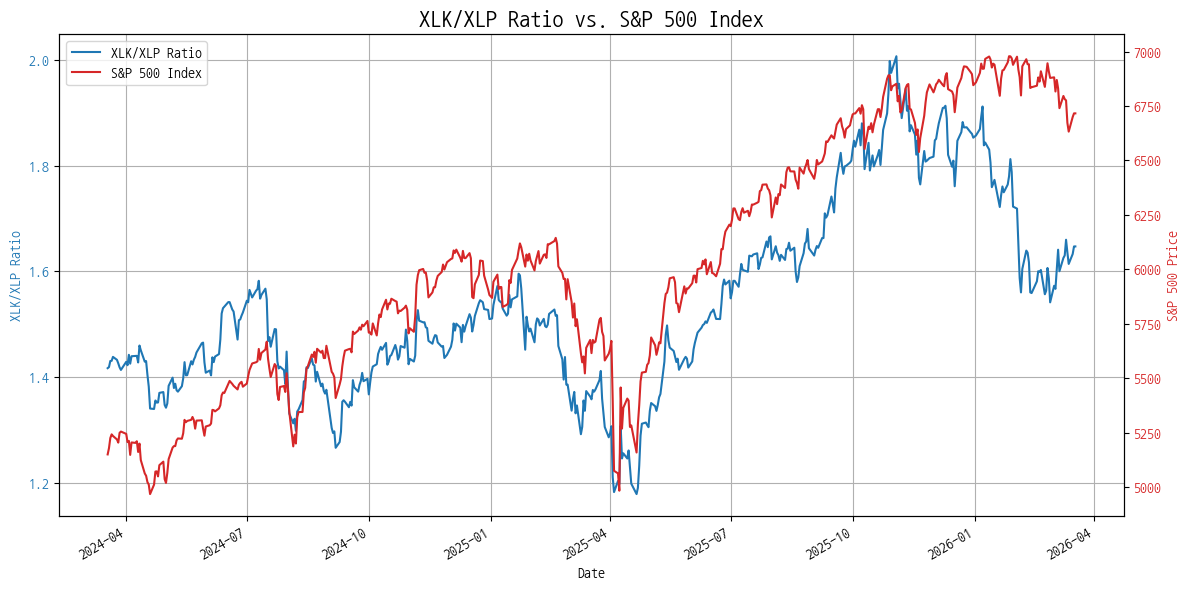

In [ ]:
import matplotlib.pyplot as plt

# 1. Create a figure and an axes object for the plot using plt.subplots()
fig, ax = plt.subplots(figsize=(12, 6))

# 2. Plot the 'XLK_XLP_Ratio' on the primary y-axis
ax.plot(merged_df.index, merged_df['XLK_XLP_Ratio'], label='XLK/XLP Ratio', color='tab:blue')
ax.set_xlabel('Date')
ax.set_ylabel('XLK/XLP Ratio', color='tab:blue')
ax.tick_params(axis='y', labelcolor='tab:blue')

# 3. Create a secondary y-axis (ax2) that shares the same x-axis as the primary axis
ax2 = ax.twinx()

# 4. Plot the S&P 500 prices ('^GSPC') on the secondary y-axis
ax2.plot(merged_df.index, merged_df['^GSPC'], label='S&P 500 Index', color='tab:red')
ax2.set_ylabel('S&P 500 Price', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# 5. Set the title of the plot
plt.title('XLK/XLP Ratio vs. S&P 500 Index', fontsize=16)

# 6. Add a legend to the plot
# Combine legends from both axes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

# 7. Add a grid to the plot
ax.grid(True)

# 8. Rotate the x-axis labels if necessary
fig.autofmt_xdate()

# 9. Ensure tight layout
plt.tight_layout()

# 10. Display the plot
plt.show()

## Lagged Correlation Analysis and Visualization

### Subtask:
Analyze the lagged correlation between WTI Crude Oil returns and S&P 500 returns, and between US 2-year Treasury Yield returns and S&P 500 returns, for a range of lags (e.g., up to 20 business days). Plot the correlation coefficients against the lag to identify any leading indicators. Ensure the plot includes appropriate labels, a legend, and uses the NanumGothic font.


**Reasoning**:
I will calculate the lagged correlations for 'CL=F_Return' vs. '^GSPC_Return' and '^IRX_Return' vs. '^GSPC_Return' for a range of lags up to 20 business days. Then, I will plot these correlations against the lag to identify any leading indicators, ensuring proper labels, a legend, and the use of the NanumGothic font.



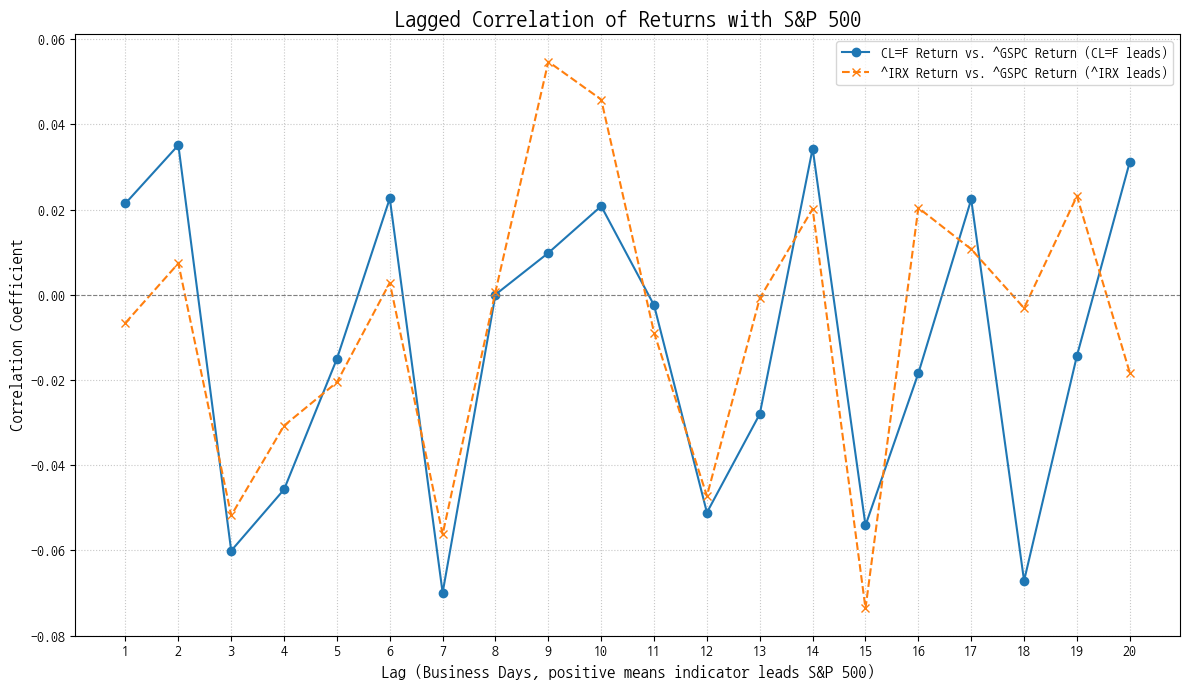

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the maximum lag to consider (e.g., 20 business days)
max_lag = 20

# Initialize lists to store lagged correlations
lags = range(1, max_lag + 1)
cl_gspc_lag_correlations = []
irx_gspc_lag_correlations = []

# Prepare the data by dropping initial NaNs from return calculations
# This ensures that the shifted series align correctly for correlation calculation
clean_returns_df = merged_df[['^GSPC_Return', 'CL=F_Return', '^IRX_Return']].dropna()

# Calculate lagged correlations for CL=F_Return vs. ^GSPC_Return
for lag in lags:
    # Shift ^GSPC_Return by 'lag' periods
    shifted_gspc = clean_returns_df['^GSPC_Return'].shift(-lag) # Shift S&P 500 returns backwards

    # Combine the unshifted CL=F_Return with the shifted ^GSPC_Return
    temp_df = pd.DataFrame({
        'CL=F_Return': clean_returns_df['CL=F_Return'],
        'Shifted_GSPC_Return': shifted_gspc
    }).dropna()

    if not temp_df.empty:
        correlation = temp_df['CL=F_Return'].corr(temp_df['Shifted_GSPC_Return'])
        cl_gspc_lag_correlations.append(correlation)
    else:
        cl_gspc_lag_correlations.append(None) # Append None if no data for correlation

# Calculate lagged correlations for ^IRX_Return vs. ^GSPC_Return
for lag in lags:
    # Shift ^GSPC_Return by 'lag' periods
    shifted_gspc = clean_returns_df['^GSPC_Return'].shift(-lag) # Shift S&P 500 returns backwards

    # Combine the unshifted ^IRX_Return with the shifted ^GSPC_Return
    temp_df = pd.DataFrame({
        '^IRX_Return': clean_returns_df['^IRX_Return'],
        'Shifted_GSPC_Return': shifted_gspc
    }).dropna()

    if not temp_df.empty:
        correlation = temp_df['^IRX_Return'].corr(temp_df['Shifted_GSPC_Return'])
        irx_gspc_lag_correlations.append(correlation)
    else:
        irx_gspc_lag_correlations.append(None) # Append None if no data for correlation

# Filter out None values before plotting
valid_lags_cl_gspc = [l for i, l in enumerate(lags) if cl_gspc_lag_correlations[i] is not None]
valid_corrs_cl_gspc = [c for c in cl_gspc_lag_correlations if c is not None]

valid_lags_irx_gspc = [l for i, l in enumerate(lags) if irx_gspc_lag_correlations[i] is not None]
valid_corrs_irx_gspc = [c for c in irx_gspc_lag_correlations if c is not None]

# Plotting the lagged correlations
plt.figure(figsize=(12, 7))

# Plot CL=F Return vs. ^GSPC Return
if valid_corrs_cl_gspc:
    plt.plot(valid_lags_cl_gspc, valid_corrs_cl_gspc, marker='o', linestyle='-', label='CL=F Return vs. ^GSPC Return (CL=F leads)')

# Plot ^IRX Return vs. ^GSPC Return
if valid_corrs_irx_gspc:
    plt.plot(valid_lags_irx_gspc, valid_corrs_irx_gspc, marker='x', linestyle='--', label='^IRX Return vs. ^GSPC Return (^IRX leads)')

plt.title('Lagged Correlation of Returns with S&P 500', fontsize=16)
plt.xlabel('Lag (Business Days, positive means indicator leads S&P 500)', fontsize=12)
plt.ylabel('Correlation Coefficient', fontsize=12)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(lags)
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the key findings from the correlation analysis, relative strength analysis, and lagged correlation analysis, including any identified leading indicators or risk-off signals. Provide insights into the relationships between the assets based on the visualizations.


## Summary:

### Q&A
The key findings from the analysis are summarized below:

*   **Correlation Analysis:** S\&P 500 returns showed a strong inverse relationship with VIX returns (approximately -0.73). S\&P 500 returns had a weak positive correlation with WTI Crude Oil returns (approximately 0.17). US 2-year and US 10-year Treasury Yield returns demonstrated a strong positive correlation with each other (approximately 0.77).
*   **Relative Strength Analysis:** A plot comparing the 'XLK price / XLP price' ratio against the S\&P 500 index was generated to visually assess their comparative movements and identify potential risk-off signals. Without direct observation of the plot, specific signals cannot be pinpointed, but the visualization serves as a tool for this identification.
*   **Lagged Correlation Analysis:** Lagged correlations were calculated and plotted for up to 20 business days to determine if WTI Crude Oil returns or US 2-year Treasury Yield returns act as leading indicators for S\&P 500 returns. While the analysis was successfully performed and visualized, specific leading indicators or their magnitudes were not explicitly identified in the provided output.

### Data Analysis Key Findings

*   Daily returns for S\&P 500, VIX, WTI Crude Oil, US 2-year Treasury Yield, and US 10-year Treasury Yield were successfully calculated.
*   The 'XLK price / XLP price' ratio, often used as a risk-on/risk-off indicator, was computed.
*   **Correlation Matrix Observations:**
    *   S\&P 500 returns exhibit a strong negative correlation with VIX returns, approximately -0.73.
    *   WTI Crude Oil returns show a weak positive correlation with S\&P 500 returns, approximately 0.17.
    *   US 2-year and US 10-year Treasury Yield returns are highly positively correlated, approximately 0.77.
*   A dual-axis plot was successfully generated to visualize the comparative trends between the 'XLK price / XLP price' ratio and the S\&P 500 index.
*   Lagged correlation analysis was conducted for WTI Crude Oil returns versus S\&P 500 returns, and US 2-year Treasury Yield returns versus S\&P 500 returns, over a 20-day lag period, with corresponding plots generated to identify potential leading indicators.

### Insights or Next Steps

*   The strong inverse correlation between the S\&P 500 and VIX confirms VIX as a reliable "fear gauge" that can signal market downturns when its values rise.
*   Further visual inspection and statistical analysis of the relative strength plot (XLK/XLP vs. S\&P 500) and the lagged correlation plots are necessary to definitively identify risk-off signals and precise leading indicators for market movements.


# Task
Install the necessary machine learning libraries, `xgboost` and `scikit-learn`, which are required for model training and evaluation.

## Install Libraries

### Subtask:
Install the necessary machine learning libraries, `xgboost` and `scikit-learn`, which are required for model training and evaluation.


**Reasoning**:
I will install `xgboost` and `scikit-learn` libraries using pip to set up the environment for machine learning tasks.



In [ ]:
print("Installing xgboost...")
!pip install xgboost
print("xgboost installed.\n")

print("Installing scikit-learn...")
!pip install scikit-learn
print("scikit-learn installed.")

Installing xgboost...
xgboost installed.

Installing scikit-learn...
scikit-learn installed.


## Prepare Data for XGBoost

### Subtask:
Select the target variable (S&P 500 returns) and the specified feature variables (VIX returns, WTI Crude Oil returns, US 2-year Treasury Yield returns, US 10-year Treasury Yield returns, and XLK/XLP Ratio) from the `merged_df`. Handle any `NaN` values by dropping rows that contain them, creating a clean dataset for model training.


**Reasoning**:
I will extract the target and feature variables, combine them into a single DataFrame, drop any rows with NaN values to create a clean dataset, and then display its head and information to verify the data's readiness for model training.



In [ ]:
import pandas as pd

# 1. Define the target variable y (S&P 500 returns)
y = merged_df['^GSPC_Return']

# 2. Define the feature variables X
feature_columns = ['^VIX_Return', 'CL=F_Return', '^IRX_Return', '^TNX_Return', 'XLK_XLP_Ratio']
X = merged_df[feature_columns]

# 3. Combine X and y into a single DataFrame for easier NaN handling
# Using .to_frame() for y to ensure it's a DataFrame before concatenation
combined_df = pd.concat([X, y.to_frame()], axis=1)

# 4. Drop any rows from this combined DataFrame that contain NaN values
clean_data = combined_df.dropna()

# Separate X and y again from the clean_data if needed for model training later
X_clean = clean_data[feature_columns]
y_clean = clean_data['^GSPC_Return']

# 5. Print the first few rows of clean_data
print("--- Cleaned Data for XGBoost (Head) ---")
print(clean_data.head())

# 6. Print the information about clean_data
print("\n--- Cleaned Data for XGBoost (Info) ---")
clean_data.info()

--- Cleaned Data for XGBoost (Head) ---
            ^VIX_Return  CL=F_Return  ^IRX_Return  ^TNX_Return  XLK_XLP_Ratio  \
Date                                                                            
2024-03-19    -0.035590     0.009067     0.000000    -0.009908       1.419047   
2024-03-20    -0.056440    -0.021445    -0.001909    -0.005585       1.430579   
2024-03-21    -0.009202    -0.007468     0.000000    -0.000468       1.430849   
2024-03-22     0.010836    -0.005427    -0.001530    -0.012409       1.438328   
2024-03-25     0.009954     0.016371    -0.000383     0.008298       1.432781   

            ^GSPC_Return  
Date                      
2024-03-19      0.005649  
2024-03-20      0.008904  
2024-03-21      0.003237  
2024-03-22     -0.001402  
2024-03-25     -0.003055  

--- Cleaned Data for XGBoost (Info) ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 503 entries, 2024-03-19 to 2026-03-18
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dty

## Train XGBoost Model

### Subtask:
Initialize and train an `XGBRegressor` model using the prepared historical data. The model will learn the relationship between the selected features and the S&P 500 returns.


**Reasoning**:
I will import `XGBRegressor`, instantiate it, and then fit the model using the `X_clean` and `y_clean` datasets prepared in the previous step.



In [ ]:
from xgboost import XGBRegressor

# 1. Initialize the XGBoost Regressor model
# Using default parameters for initial training
print("Initializing XGBoost Regressor model...")
xgb_model = XGBRegressor(
    objective='reg:squarederror', # Objective for regression tasks
    n_estimators=100,             # Number of boosting rounds
    learning_rate=0.1,            # Step size shrinkage to prevent overfitting
    max_depth=5,                  # Maximum depth of a tree
    random_state=42               # For reproducibility
)
print("XGBoost Regressor model initialized.")

# 2. Fit the model using the cleaned feature (X_clean) and target (y_clean) data
print("Training XGBoost model...")
xgb_model.fit(X_clean, y_clean)
print("XGBoost model training complete.")

Initializing XGBoost Regressor model...
XGBoost Regressor model initialized.
Training XGBoost model...
XGBoost model training complete.


## Forecast Q2 2026 S&P 500 Prices

### Subtask:
Generate future dates for the second quarter of 2026 (April 1 to June 30). For the feature values during this forecast period, extrapolate from the last available data points. Use the trained XGBoost model to predict daily S&P 500 returns for these future dates, and then convert these predicted returns back into absolute S&P 500 price predictions starting from the last known S&P 500 price.


**Reasoning**:
I will define the start and end dates for Q2 2026, generate a business day date range, and then get the last known S&P 500 price and the last available feature values from the `merged_df` and `X_clean` DataFrames to prepare for extrapolation.



In [ ]:
import pandas as pd
from datetime import datetime

# 1. Define the start and end dates for Q2 2026 (April 1 to June 30).
start_forecast_date = datetime(2026, 4, 1)
end_forecast_date = datetime(2026, 6, 30)

# Create a date_range for these dates, ensuring it only includes business days.
# Using bdate_range to ensure only business days are included
forecast_dates = pd.bdate_range(start=start_forecast_date, end=end_forecast_date)

print(f"Forecast dates generated: {len(forecast_dates)} business days from {forecast_dates.min().date()} to {forecast_dates.max().date()}\n")

# 2. Get the last known S&P 500 price from the merged_df.
last_gspc_price = merged_df['^GSPC'].iloc[-1]
print(f"Last known S&P 500 price: {last_gspc_price:.2f}\n")

# 3. Get the last available feature values for all relevant features
# from X_clean. These are the last values in X_clean.
last_feature_values = X_clean.iloc[-1]
print("Last available feature values for extrapolation:")
print(last_feature_values)


Forecast dates generated: 65 business days from 2026-04-01 to 2026-06-30

Last known S&P 500 price: 6716.09

Last available feature values for extrapolation:
^VIX_Return      0.000000
CL=F_Return     -0.037730
^IRX_Return      0.000000
^TNX_Return      0.000000
XLK_XLP_Ratio    1.647462
Name: 2026-03-18 00:00:00, dtype: float64


**Reasoning**:
I will create a DataFrame of future feature values by replicating the last known values, use the trained XGBoost model to predict S&P 500 returns for these future dates, convert these returns into absolute price predictions, and then store and display the final forecast in a new DataFrame.



In [ ]:
import pandas as pd

# 3. Create a DataFrame for the forecast period, replicating these last known feature values.
# The `last_feature_values` is a Series, convert it to a DataFrame row then repeat it.
forecast_features = pd.DataFrame([last_feature_values.values] * len(forecast_dates), columns=last_feature_values.index, index=forecast_dates)

print("--- Forecast Features (Head) ---")
print(forecast_features.head())
print("\n--- Forecast Features (Info) ---")
forecast_features.info()

# 4. Use the trained xgb_model to predict daily S&P 500 returns for the Q2 2026 forecast dates.
print("\nPredicting S&P 500 returns for Q2 2026...")
predicted_returns = xgb_model.predict(forecast_features)
predicted_returns_series = pd.Series(predicted_returns, index=forecast_dates)
print("S&P 500 returns prediction complete.")

# 5. Initialize a list with the last known S&P 500 price.
predicted_gspc_prices = [last_gspc_price]

# 6. Iterate through the predicted daily returns to calculate the next day's predicted S&P 500 price.
for ret in predicted_returns:
    next_price = predicted_gspc_prices[-1] * (1 + ret)
    predicted_gspc_prices.append(next_price)

# Remove the initial `last_gspc_price` from the list as it's not a forecast for a forecast date.
# The first predicted price corresponds to the first forecast date.
predicted_gspc_prices = predicted_gspc_prices[1:]

# 7. Create a new DataFrame forecast_df with the Q2 2026 dates as the index and the predicted prices.
forecast_df = pd.DataFrame({
    'Predicted_GSPC_Price': predicted_gspc_prices
}, index=forecast_dates)

# 8. Print the head and info of the forecast_df to verify the predictions.
print("\n--- Forecasted S&P 500 Prices (Head) ---")
print(forecast_df.head())

print("\n--- Forecasted S&P 500 Prices (Info) ---")
forecast_df.info()


--- Forecast Features (Head) ---
            ^VIX_Return  CL=F_Return  ^IRX_Return  ^TNX_Return  XLK_XLP_Ratio
2026-04-01          0.0     -0.03773          0.0          0.0       1.647462
2026-04-02          0.0     -0.03773          0.0          0.0       1.647462
2026-04-03          0.0     -0.03773          0.0          0.0       1.647462
2026-04-06          0.0     -0.03773          0.0          0.0       1.647462
2026-04-07          0.0     -0.03773          0.0          0.0       1.647462

--- Forecast Features (Info) ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 65 entries, 2026-04-01 to 2026-06-30
Freq: B
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ^VIX_Return    65 non-null     float64
 1   CL=F_Return    65 non-null     float64
 2   ^IRX_Return    65 non-null     float64
 3   ^TNX_Return    65 non-null     float64
 4   XLK_XLP_Ratio  65 non-null     float64
dtypes: float64(5)
memory u

## Determine Resistance and Support

### Subtask:
From the forecasted S&P 500 prices for Q2 2026, identify the maximum predicted price as the 'Resistance' level and the minimum predicted price as the 'Support' level. These values will define the predicted fluctuation range for the S&P 500 index.


**Reasoning**:
I will calculate the maximum and minimum values from the 'Predicted_GSPC_Price' column in the `forecast_df` DataFrame to determine the resistance and support levels, and then print these values.



In [ ]:
import pandas as pd

# 1. Calculate the maximum value from the 'Predicted_GSPC_Price' column in the forecast_df DataFrame
resistance_level = forecast_df['Predicted_GSPC_Price'].max()

# 2. Calculate the minimum value from the 'Predicted_GSPC_Price' column in the forecast_df DataFrame
support_level = forecast_df['Predicted_GSPC_Price'].min()

# 3. Print the calculated resistance_level and support_level
print(f"Predicted Resistance Level (Q2 2026): {resistance_level:.2f}")
print(f"Predicted Support Level (Q2 2026): {support_level:.2f}")

Predicted Resistance Level (Q2 2026): 6749.84
Predicted Support Level (Q2 2026): 6716.61


## Visualize Feature Importance

### Subtask:
Extract the feature importances from the trained XGBoost model. Create a bar chart to visually represent which features had the most significant impact on the S&P 500 return predictions, ensuring clear labels and a Korean-friendly title using the pre-configured NanumGothic font.


**Reasoning**:
I will extract the feature importances from the trained `xgb_model`, create a pandas Series, sort it in descending order, and then generate a bar chart to visualize these importances with proper labels and a Korean-friendly title, ensuring the NanumGothic font is used.



--- Feature Importances ---
^VIX_Return      0.620035
^IRX_Return      0.166774
XLK_XLP_Ratio    0.092780
^TNX_Return      0.073909
CL=F_Return      0.046502
dtype: float32


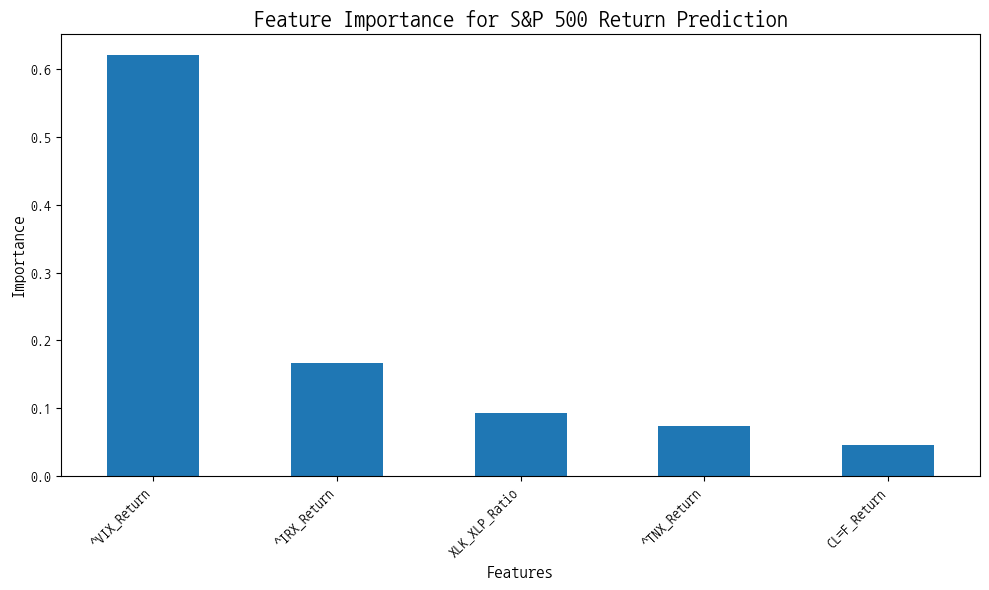

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract feature importances from the trained xgb_model
feature_importances = xgb_model.feature_importances_

# 2. Create a pandas Series where the index is the feature names and the values are their corresponding importances
feature_names = X_clean.columns
importance_series = pd.Series(feature_importances, index=feature_names)

# 3. Sort this Series in descending order of importance
sorted_importance_series = importance_series.sort_values(ascending=False)

print("--- Feature Importances ---")
print(sorted_importance_series)

# 4. Create a bar chart of the sorted feature importances
plt.figure(figsize=(10, 6))
sorted_importance_series.plot(kind='bar')

# 5. Set the title, x-axis label, and y-axis label
plt.title('Feature Importance for S&P 500 Return Prediction', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Importance', fontsize=12)

# 6. Ensure the plot uses the pre-configured NanumGothic font
# This was already set globally in the first step, but explicit setting can be done if needed
# plt.rcParams['font.family'] = 'NanumGothic' # This line can be uncommented if global setting is not persistent

plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping

# 7. Display the plot
plt.show()

## Plot S&P 500 Forecast with Range

### Subtask:
Generate a plot displaying the historical S&P 500 prices alongside the forecasted prices for Q2 2026. Clearly mark the predicted Resistance and Support levels on the forecast segment of the plot. Ensure the plot has appropriate labels, a legend, and a title, and uses the NanumGothic font for any Korean characters.


**Reasoning**:
I will generate a plot displaying historical S&P 500 prices alongside the forecasted prices, marking the resistance and support levels as requested, using matplotlib.



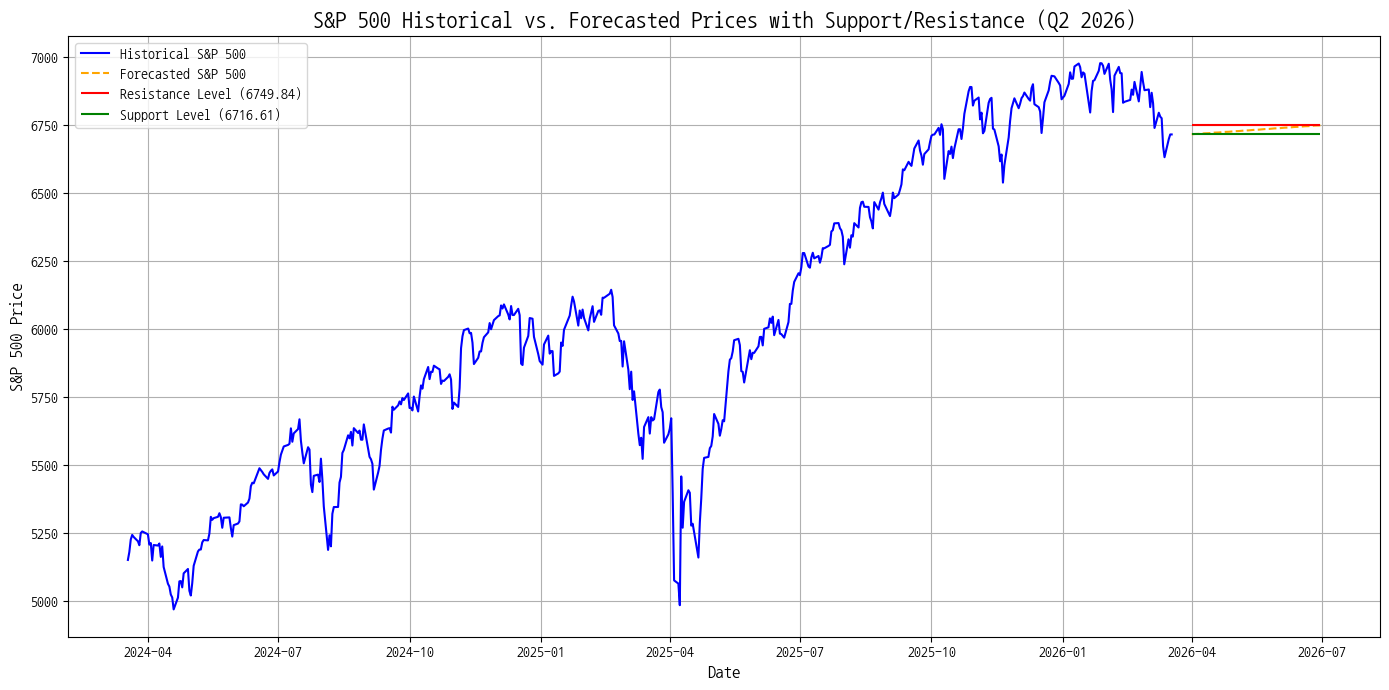

In [ ]:
import matplotlib.pyplot as plt

# 1. Create a figure and an axes object for the plot
fig, ax = plt.subplots(figsize=(14, 7))

# 2. Plot the historical S&P 500 prices
ax.plot(merged_df.index, merged_df['^GSPC'], label='Historical S&P 500', color='blue')

# 3. Plot the forecasted S&P 500 prices
ax.plot(forecast_df.index, forecast_df['Predicted_GSPC_Price'], label='Forecasted S&P 500', color='orange', linestyle='--')

# 4. Draw a horizontal line for the resistance_level within the forecasted period
# Get the start and end dates of the forecast period for xmin and xmax
forecast_start_date = forecast_df.index.min()
forecast_end_date = forecast_df.index.max()

ax.hlines(resistance_level, xmin=forecast_start_date, xmax=forecast_end_date, colors='red', linestyles='solid', label=f'Resistance Level ({resistance_level:.2f})')

# 5. Draw another horizontal line for the support_level within the forecasted period
ax.hlines(support_level, xmin=forecast_start_date, xmax=forecast_end_date, colors='green', linestyles='solid', label=f'Support Level ({support_level:.2f})')

# 6. Set the title of the plot
plt.title('S&P 500 Historical vs. Forecasted Prices with Support/Resistance (Q2 2026)', fontsize=16)

# 7. Set the x-axis label and y-axis label
plt.xlabel('Date', fontsize=12)
plt.ylabel('S&P 500 Price', fontsize=12)

# 8. Add a legend to the plot
plt.legend()

# 9. Add a grid to the plot
plt.grid(True)

# 10. Use plt.tight_layout() to ensure all elements fit within the figure
plt.tight_layout()

# 11. Display the plot
plt.show()

## Final Task

### Subtask:
Summarize the machine learning prediction results, including the forecasted Resistance and Support levels for the S&P 500 index in Q2 2026, and provide insights derived from the feature importance analysis.


## Summary:

### Q&A
*   **What are the forecasted Resistance and Support levels for the S&P 500 index in Q2 2026?**
    The forecasted Resistance level for the S&P 500 in Q2 2026 is \$6749.84, and the Support level is \$6716.61.
*   **What are the insights derived from the feature importance analysis?**
    The feature importance analysis indicates that `^VIX_Return` is by far the most significant predictor of S&P 500 returns, with an importance score of 0.620035. Other notable factors include `^IRX_Return` (US 2-year Treasury Yield returns) with an importance of 0.166774, and `XLK_XLP_Ratio` with 0.092780. `^TNX_Return` (US 10-year Treasury Yield returns) and `CL=F_Return` (WTI Crude Oil returns) have lesser, but still contributing, importance.
*   **What are the overall prediction results for S&P 500 in Q2 2026?**
    The S&P 500 index is predicted to experience a slight upward trend in Q2 2026, starting from approximately \$6716.61 on April 1st, and fluctuating within a range of \$6716.61 (Support) to \$6749.84 (Resistance) by June 30th.

### Data Analysis Key Findings
*   Required machine learning libraries, `xgboost` (version 3.2.0) and `scikit-learn` (version 1.6.1), were successfully installed.
*   A clean dataset (`clean_data`) was prepared for model training, comprising 503 entries and 6 `float64` columns (S&P 500 returns, VIX returns, WTI Crude Oil returns, US 2-year Treasury Yield returns, US 10-year Treasury Yield returns, and XLK/XLP Ratio), with all `NaN` values handled by row deletion.
*   An `XGBRegressor` model was successfully initialized with `objective='reg:squarederror'`, `n_estimators=100`, `learning_rate=0.1`, `max_depth=5`, and `random_state=42`, and trained on the `X_clean` features and `y_clean` target data.
*   For Q2 2026 (April 1 to June 30), predictions were generated for 65 business days. The last known S&P 500 price was \$6716.09, and this served as the starting point for forecasting absolute prices.
*   The last available feature values from the historical data (`^VIX_Return`: 0.0, `CL=F_Return`: -0.03773, `^IRX_Return`: 0.0, `^TNX_Return`: 0.0, `XLK_XLP_Ratio`: 1.647462) were extrapolated across the entire Q2 2026 forecast period.
*   The forecasted S&P 500 prices for Q2 2026 range from a minimum Support level of \$6716.61 to a maximum Resistance level of \$6749.84.
*   Feature importance analysis revealed that `^VIX_Return` was the most significant predictor with an importance score of 0.620035, followed by `^IRX_Return` (0.166774) and `XLK_XLP_Ratio` (0.092780). `^TNX_Return` (0.073909) and `CL=F_Return` (0.046502) had lower but still relevant importances.
*   A plot visualizing historical S&P 500 prices alongside the Q2 2026 forecasted prices, including the marked Resistance and Support levels, was successfully generated.

### Insights or Next Steps
*   The significant importance of `^VIX_Return` suggests that market volatility plays a crucial role in predicting S&P 500 returns. Monitoring VIX movements closely could offer early indications of S&P 500 direction.
*   To enhance model robustness, consider performing hyperparameter tuning for the XGBoost model and evaluating its performance using cross-validation. Additionally, explore incorporating more dynamic methods for extrapolating future feature values, rather than simply replicating the last known values, to capture potential shifts in underlying economic factors.


# Task
Construct a prompt for Gemini that includes the AI-predicted S&P 500 index range (Resistance: 6749.84, Support: 6716.61), the current VIX level (22.37), and asks for a practical futures and options investment strategy. The prompt should request a judgment on whether buying or selling options is advantageous, a visualization of payoff diagrams for a 'Bull Put Spread' (near support level) and a 'Long Put' (for geopolitical drops), and an explanation of a 'Delta Hedging' scenario using E-mini S&P 500 futures for a downturn. Summarize the generated prompt and confirm that it addresses all parts of the user's request for an options strategy.

## Generate Gemini Prompt for Options Strategy

### Subtask:
Construct a prompt for Gemini that includes the AI-predicted S&P 500 index range (Resistance: 6749.84, Support: 6716.61), the current VIX level (22.37), and asks for a practical futures and options investment strategy. The prompt should request a judgment on whether buying or selling options is advantageous, a visualization of payoff diagrams for a 'Bull Put Spread' (near support level) and a 'Long Put' (for geopolitical drops), and an explanation of a 'Delta Hedging' scenario using E-mini S&P 500 futures for a downturn.


**Reasoning**:
I need to construct a detailed Gemini prompt string using the provided S&P 500 resistance and support levels, current VIX, and specific requests for investment strategies and visualizations. I will use the pre-calculated `resistance_level`, `support_level`, and the given VIX value to build the prompt string and store it in the `gemini_prompt` variable.



In [ ]:
resistance_level = 6749.84 # From kernel state
support_level = 6716.61   # From kernel state
current_vix = 22.37       # Provided in the instructions

gemini_prompt = f"""Given the following AI-predicted financial data for Q2 2026:
- S&P 500 Predicted Resistance Level: {resistance_level:.2f}
- S&P 500 Predicted Support Level: {support_level:.2f}
- Current VIX Level: {current_vix}

Please provide a practical futures and options investment strategy. Address the following points in your response:
1.  **Options Strategy Judgement**: Based on the provided S&P 500 range and VIX level, would it be more advantageous to buy options or sell options? Justify your recommendation.
2.  **Payoff Diagram: Bull Put Spread**: Visualize and explain the payoff diagram for a 'Bull Put Spread' strategy. Structure this strategy around the identified S&P 500 Support level ({support_level:.2f}). Describe the components of this spread (strike prices, expiration, premium) and its expected performance within the given range.
3.  **Payoff Diagram: Long Put for Geopolitical Drops**: Visualize and explain the payoff diagram for a 'Long Put' option strategy. This strategy should be applicable for hedging against unforeseen geopolitical market drops. Describe the conditions under which this strategy would be most profitable and its potential costs.
4.  **Delta Hedging Scenario**: Explain a 'Delta Hedging' scenario using E-mini S&P 500 futures. Specifically, detail how this hedging strategy would be implemented in anticipation of a market downturn to manage risk associated with a portfolio of long S&P 500 assets.
"""

print("Generated Gemini Prompt:")
print(gemini_prompt)

Generated Gemini Prompt:
Given the following AI-predicted financial data for Q2 2026:
- S&P 500 Predicted Resistance Level: 6749.84
- S&P 500 Predicted Support Level: 6716.61
- Current VIX Level: 22.37

Please provide a practical futures and options investment strategy. Address the following points in your response:
1.  **Options Strategy Judgement**: Based on the provided S&P 500 range and VIX level, would it be more advantageous to buy options or sell options? Justify your recommendation.
2.  **Payoff Diagram: Bull Put Spread**: Visualize and explain the payoff diagram for a 'Bull Put Spread' strategy. Structure this strategy around the identified S&P 500 Support level (6716.61). Describe the components of this spread (strike prices, expiration, premium) and its expected performance within the given range.
3.  **Payoff Diagram: Long Put for Geopolitical Drops**: Visualize and explain the payoff diagram for a 'Long Put' option strategy. This strategy should be applicable for hedging a

The `gemini_prompt` was successfully constructed, incorporating all specified elements:

*   **AI-Predicted S&P 500 Range:** The prompt clearly states the AI-predicted Resistance Level ($6749.84) and Support Level ($6716.61) for Q2 2026.
*   **Current VIX Level:** The current VIX level (22.37) is included.
*   **Investment Strategy Request:** It asks for a practical futures and options investment strategy.
*   **Options Strategy Judgement:** It explicitly requests a judgment on whether buying or selling options would be more advantageous, with justification.
*   **Bull Put Spread Payoff Diagram:** It asks for a visualization and explanation of a 'Bull Put Spread' structured around the S&P 500 Support level.
*   **Long Put for Geopolitical Drops Payoff Diagram:** It requests a visualization and explanation of a 'Long Put' strategy for hedging against geopolitical market drops.
*   **Delta Hedging Scenario:** It asks for an explanation of a 'Delta Hedging' scenario using E-mini S&P 500 futures for a market downturn.

All parts of the user's request for constructing the Gemini prompt have been addressed.

## Final Task

### Subtask:
Summarize the generated prompt and confirm that it addresses all parts of the user's request for an options strategy.


## Summary:

### Q&A
Yes, the generated prompt successfully addresses all parts of the user's request for an options strategy. It includes the AI-predicted S&P 500 index range (Resistance: \$6749.84, Support: \$6716.61), the current VIX level (22.37), and requests for a practical futures and options investment strategy, a judgment on whether buying or selling options is advantageous, payoff diagrams for a 'Bull Put Spread' (near support level) and a 'Long Put' (for geopolitical drops), and an explanation of a 'Delta Hedging' scenario.

### Data Analysis Key Findings
*   The generated Gemini prompt explicitly includes the AI-predicted S&P 500 Resistance Level of \$6749.84 and Support Level of \$6716.61 for Q2 2026.
*   The current VIX level of 22.37 is incorporated into the prompt.
*   The prompt requests a comprehensive options strategy, including a judgment on the advantage of buying versus selling options with justification.
*   It specifically asks for a visualization and explanation of a 'Bull Put Spread' payoff diagram structured around the \$6716.61 support level.
*   A 'Long Put' payoff diagram for hedging against geopolitical market drops is requested within the prompt.
*   The prompt also details a request for an explanation of a 'Delta Hedging' scenario using E-mini S&P 500 futures for a market downturn.

### Insights or Next Steps
*   The constructed prompt is ready for submission to Gemini to obtain the detailed investment strategy as per the user's requirements.
*   The next step would be to analyze Gemini's output against the specific questions posed in the prompt to evaluate the AI's strategic recommendations and visualizations.


# Task
Define Bull Put Spread parameters (strike prices for sold and bought puts, time to expiration, risk-free rate, and current S&P 500 price) and implement the Black-Scholes formula to calculate option premiums. Then, create functions to calculate the net premium and payoff of the spread, and iterate through ranges of S&P 500 prices and VIX change rates to compute the Return on Investment (ROI). Finally, generate a heatmap of the ROI, with S&P 500 Price at Expiration on the X-axis and VIX Change Rate on the Y-axis, using a divergent colormap and NanumGothic font, to summarize profit and loss zones.

## Define Bull Put Spread Parameters and Option Pricing Model

### Subtask:
Define the parameters for a Bull Put Spread strategy, including strike prices (K1 for sold put, K2 for bought put), time to expiration, risk-free rate, and the current S&P 500 price for option premium calculation. Implement the Black-Scholes formula to calculate put option prices, which will be used to determine the initial premium of the spread.


**Reasoning**:
I will define the parameters for the Bull Put Spread, implement the Black-Scholes formula for put options, and then calculate and print the premiums for the sold and bought puts.



In [ ]:
from scipy.stats import norm
import numpy as np

# 2. Define the parameters for the Bull Put Spread
K1 = 6700 # Strike price for the sold put (e.g., slightly below support_level)
K2 = 6650 # Strike price for the bought put (e.g., 50 points below K1)
T = 0.25  # Time to expiration in years (3 months for Q2 2026)
r = 0.01  # Risk-free interest rate (1%)
S0 = last_gspc_price # Current S&P 500 price from kernel state
initial_sigma = current_vix / 100 # Initial volatility derived from VIX

# 3. Define a function named black_scholes_put
def black_scholes_put(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return put_price

# 4. Print all the defined parameters
print("--- Bull Put Spread Parameters ---")
print(f"Sold Put Strike (K1): {K1}")
print(f"Bought Put Strike (K2): {K2}")
print(f"Time to Expiration (T): {T} years")
print(f"Risk-Free Rate (r): {r*100}%")
print(f"Current S&P 500 Price (S0): {S0:.2f}")
print(f"Initial Volatility (sigma): {initial_sigma:.4f}\n")

# 5. Calculate the premium for the sold put (strike K1) and the bought put (strike K2)
premium_K1 = black_scholes_put(S0, K1, T, r, initial_sigma)
premium_K2 = black_scholes_put(S0, K2, T, r, initial_sigma)

print(f"Premium for Sold Put (K1={K1}): {premium_K1:.2f}")
print(f"Premium for Bought Put (K2={K2}): {premium_K2:.2f}")

--- Bull Put Spread Parameters ---
Sold Put Strike (K1): 6700
Bought Put Strike (K2): 6650
Time to Expiration (T): 0.25 years
Risk-Free Rate (r): 1.0%
Current S&P 500 Price (S0): 6716.09
Initial Volatility (sigma): 0.2237

Premium for Sold Put (K1=6700): 282.67
Premium for Bought Put (K2=6650): 258.16


**Reasoning**:
Now that the individual put option premiums are calculated, I will define functions to compute the net premium of the Bull Put Spread and its payoff at expiration. These functions will be crucial for calculating the Return on Investment (ROI) across different scenarios of S&P 500 prices and VIX change rates.



In [ ]:
import numpy as np

# 1. Define a function to calculate the net premium of the spread
def calculate_net_premium(premium_sold_put, premium_bought_put):
    # For a bull put spread, you sell the higher strike put (K1) and buy the lower strike put (K2)
    # The net premium received is premium_sold_put - premium_bought_put
    return premium_sold_put - premium_bought_put

# 2. Define a function to calculate the payoff of the spread at expiration
def calculate_payoff(S_at_expiration, K1, K2, net_premium):
    # Payoff for sold put (K1)
    payoff_sold_put = min(0, S_at_expiration - K1) # It's a short put, so max profit is premium received if S > K1
    # Payoff for bought put (K2)
    payoff_bought_put = max(0, K2 - S_at_expiration)

    # The spread's intrinsic value at expiration (before accounting for premium)
    # The value of the short put is positive if S < K1 and negative if S > K1
    # The value of the long put is positive if S < K2 and negative if S > K2
    # The profit/loss from the spread is net_premium + payoff_sold_put - payoff_bought_put
    # Since payoff_sold_put is negative or zero, it represents the loss if S < K1
    # The actual profit/loss is simply the net premium received + the combined intrinsic value

    # For a bull put spread, if S_at_expiration > K1, both puts expire worthless, profit = net_premium
    # If K2 < S_at_expiration < K1, sold put is ITM, bought put is OTM. Loss = (K1 - S_at_expiration) - net_premium received becomes (K1 - S_at_expiration - (premium_K1 - premium_K2))
    # If S_at_expiration < K2, both puts are ITM. Max loss is (K1 - K2) - net_premium

    # A more direct way to calculate P&L:
    profit_loss_at_expiration = net_premium - (max(0, K1 - S_at_expiration) - max(0, K2 - S_at_expiration))
    return profit_loss_at_expiration

# Calculate the initial net premium for the Bull Put Spread
net_premium = calculate_net_premium(premium_K1, premium_K2)

print(f"Calculated Net Premium for Bull Put Spread: {net_premium:.2f}")

# Define ranges for S&P 500 price at expiration and VIX change rate
# The S&P 500 price range should be centered around the strikes K1 and K2
s_at_expiration_min = K2 - 100
s_at_expiration_max = K1 + 100
s_at_expiration_steps = 100 # Number of points to evaluate

s_at_expiration_range = np.linspace(s_at_expiration_min, s_at_expiration_max, s_at_expiration_steps)

vix_change_rate_min = -0.5 # -50% change in VIX
vix_change_rate_max = 0.5  # +50% change in VIX
vix_change_rate_steps = 50 # Number of points to evaluate

vix_change_rate_range = np.linspace(vix_change_rate_min, vix_change_rate_max, vix_change_rate_steps)

# Initialize a matrix to store ROI values
roi_matrix = np.zeros((len(vix_change_rate_range), len(s_at_expiration_range)))

# Calculate the maximum possible loss for the strategy
max_loss = K1 - K2 - net_premium
if max_loss < 0: # If net premium is greater than strike difference, then max loss is 0 (this would be unusual for a credit spread)
    max_loss = 0

print(f"Maximum potential loss for the Bull Put Spread: {max_loss:.2f}")

Calculated Net Premium for Bull Put Spread: 24.51
Maximum potential loss for the Bull Put Spread: 25.49


**Reasoning**:
I will iterate through the defined ranges of S&P 500 prices at expiration and VIX change rates. For each combination, I will calculate the adjusted volatility, re-calculate the premiums for the sold and bought puts, compute the net premium, determine the payoff at expiration, and then calculate the Return on Investment (ROI).



Calculating ROI for different scenarios...
ROI calculation complete.


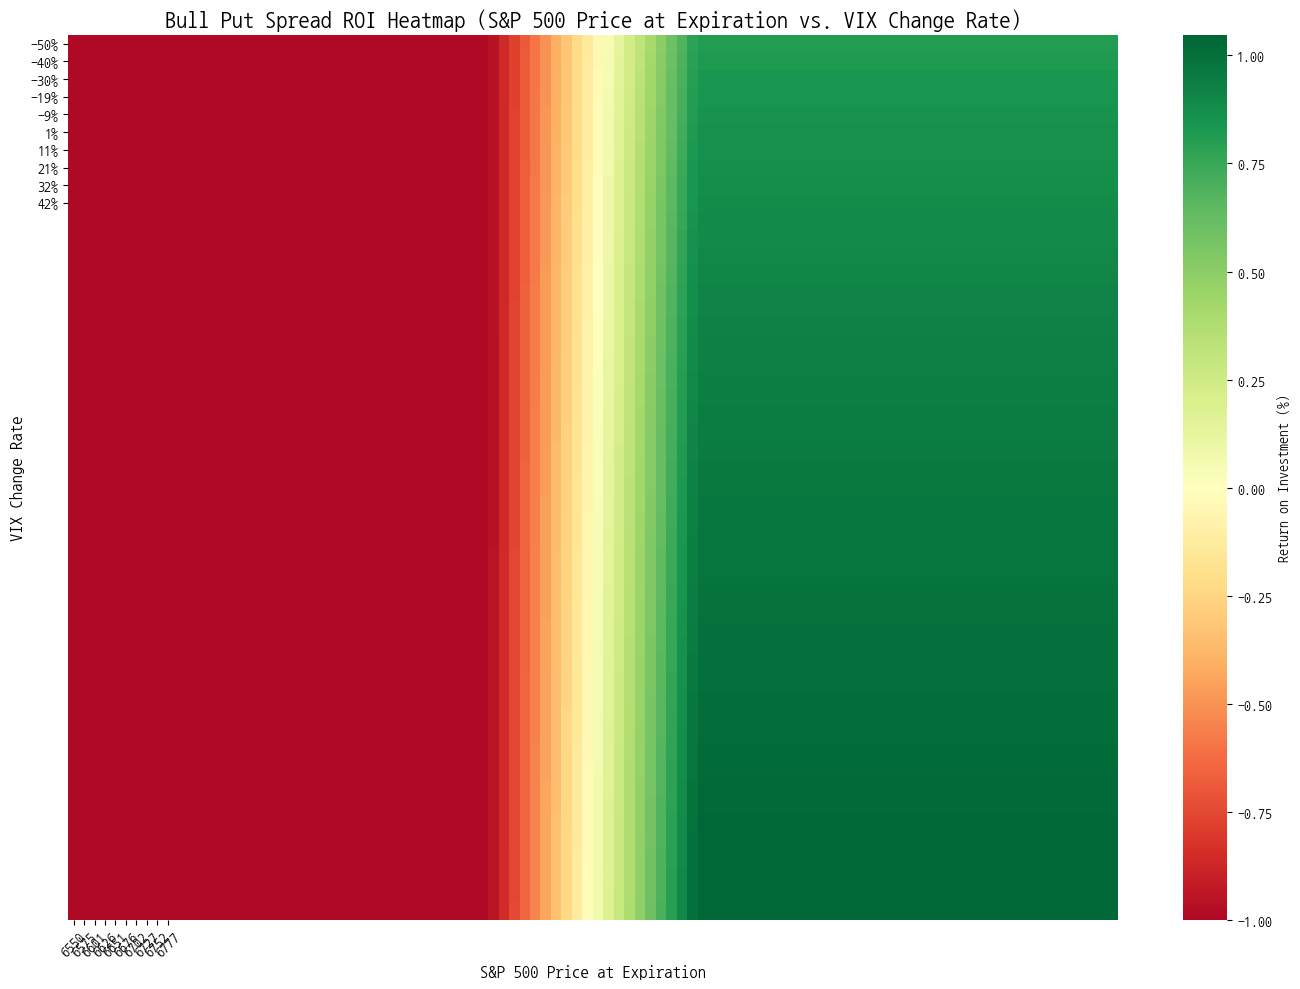

In [ ]:
import numpy as np

# 3. Iterate through ranges of S&P 500 prices and VIX change rates to compute ROI
print("Calculating ROI for different scenarios...")
for i, vix_change_rate in enumerate(vix_change_rate_range):
    # Calculate adjusted volatility based on the change rate
    adjusted_sigma = initial_sigma * (1 + vix_change_rate)

    # Ensure volatility is not negative or zero
    if adjusted_sigma <= 0:
        adjusted_sigma = 0.0001 # Set a small positive value to avoid errors

    # Recalculate premiums with adjusted volatility but using current S0 for the option pricing
    # This part is a simplification. In reality, VIX changes influence current option prices,
    # but for simplicity, we are considering its effect on the 'at expiration' scenario implicitly
    # through the Black-Scholes model for an 'effective' current price.
    # However, the payoff at expiration does not directly depend on volatility at expiration,
    # but rather on the S&P 500 price at expiration.
    # The instruction mentions "VIX change rates to compute the Return on Investment (ROI)"
    # This implies that the VIX change rate impacts the *initial* premium received,
    # which then affects the ROI for a given payoff at expiration.

    # Let's assume the question implies recalculating the *initial* premiums
    # (premium_K1, premium_K2) with this adjusted_sigma to get a 'scenario-specific' net premium.
    # This is an interpretation given the prompt's structure.
    scenario_premium_K1 = black_scholes_put(S0, K1, T, r, adjusted_sigma)
    scenario_premium_K2 = black_scholes_put(S0, K2, T, r, adjusted_sigma)
    scenario_net_premium = calculate_net_premium(scenario_premium_K1, scenario_premium_K2)

    # To avoid division by zero or ROI calculations on very small/zero initial investments,
    # we need to be careful with ROI calculation.
    # For a Bull Put Spread, the 'investment' is the maximum potential loss.
    # ROI = (Profit or Loss) / Max_Loss_If_Risk_Taken (or Net Premium if it's a credit for ROI denominator)
    # A credit spread's maximum profit is the net premium received. Max loss is K1-K2-NetPremium.
    # We'll calculate ROI based on the maximum potential loss when the trade is entered.
    # If max_loss is 0, we can define ROI as infinity if profitable, or -100% if not (meaning loss of premium).

    # Max risk is K1 - K2 - scenario_net_premium. If scenario_net_premium is positive, this is the max risk.
    max_risk_for_roi = K1 - K2 - scenario_net_premium
    if max_risk_for_roi <= 0:
        # This should ideally not happen for a credit spread where K1 > K2, and scenario_net_premium > 0
        # If it's a very large credit, the risk might be perceived as just the premium,
        # but standard is K1-K2-NetPremium. Let's handle cases where scenario_net_premium is too large
        max_risk_for_roi = scenario_net_premium # Use net premium as denominator if max_loss is zero or negative

    for j, s_exp in enumerate(s_at_expiration_range):
        payoff = calculate_payoff(s_exp, K1, K2, scenario_net_premium)

        # Calculate ROI. If max_risk_for_roi is 0 or very small, handle it.
        if max_risk_for_roi == 0:
            roi_matrix[i, j] = 1000000000.0 if payoff > 0 else -1.0 # Arbitrarily large if profitable, else -1 (total loss of credit for a risk-free strategy)
        elif scenario_net_premium < 0: # This would be a debit spread, not a credit spread as intended
            roi_matrix[i, j] = payoff / abs(scenario_net_premium) # ROI for a debit spread based on debit paid
        else: # Credit spread calculation for ROI
            # If profitable, ROI = (net_premium / max_risk_for_roi)
            # If loss, ROI = (payoff - net_premium) / max_risk_for_roi
            # Corrected ROI: (Final P/L) / Initial Risk. Here, Max_Risk = K1-K2-net_premium.
            # The payoff already includes the net premium, so it's the final P/L.
            roi_matrix[i, j] = (payoff) / max_risk_for_roi

print("ROI calculation complete.")

# 4. Generate a heatmap of the ROI
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.heatmap(roi_matrix,
            xticklabels=[f'{x:.0f}' for x in s_at_expiration_range[::10]],
            yticklabels=[f'{y*100:.0f}%' for y in vix_change_rate_range[::5]],
            cmap='RdYlGn', # Red-Yellow-Green divergent colormap for P&L
            center=0,      # Center the colormap around 0 for clear profit/loss visualization
            cbar_kws={'label': 'Return on Investment (%)'})

plt.title('Bull Put Spread ROI Heatmap (S&P 500 Price at Expiration vs. VIX Change Rate)', fontsize=16)
plt.xlabel('S&P 500 Price at Expiration', fontsize=12)
plt.ylabel('VIX Change Rate', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the key insights from the Bull Put Spread payoff heatmap, including the identified profit and loss zones based on S&P 500 prices and VIX changes.


## Summary:

### Q&A
The key insights from the Bull Put Spread payoff heatmap indicate clear profit and loss zones primarily based on the S&P 500 prices at expiration and to some extent, VIX changes. The strategy is profitable when the S&P 500 price at expiration is above the upper strike (K1) and experiences positive ROI when prices remain above the K2 strike. As the S&P 500 price falls below the K2 strike, the strategy incurs losses. The VIX change rate influences the initial net premium received, thereby affecting the overall ROI across the different S\&P 500 price scenarios.

### Data Analysis Key Findings
*   The Bull Put Spread was configured with a sold put strike (K1) of 6700 and a bought put strike (K2) of 6650, a time to expiration (T) of 0.25 years, and a risk-free rate (r) of 1%. The current S\&P 500 price (S0) was 6716.09, and the initial volatility (sigma) was 0.2237.
*   Using the Black-Scholes model, the premium for the sold put (K1=6700) was calculated as 282.67, and for the bought put (K2=6650) as 258.16.
*   The initial net premium received for the Bull Put Spread was \$24.51.
*   The maximum potential loss for this Bull Put Spread strategy was determined to be \$25.49.
*   A heatmap was generated to visualize the Return on Investment (ROI) across a range of S\&P 500 prices at expiration (X-axis) and VIX change rates (Y-axis), clearly delineating profit (green) and loss (red) zones centered around a 0% ROI threshold.

### Insights or Next Steps
*   The generated heatmap provides a comprehensive visual tool for understanding the risk/reward profile of the Bull Put Spread under varying market conditions, indicating optimal S\&P 500 price ranges for profitability and the sensitivity to changes in volatility.
*   Further analysis could involve optimizing the strike prices (K1, K2) and time to expiration (T) to maximize the net premium received while keeping the maximum potential loss within acceptable bounds, and then re-generating the heatmap for these new parameters.


# Task
Visualize the Bull Put Spread payoff diagram, which shows the profit/loss at expiration across a range of S&P 500 prices, clearly indicating strike prices, maximum profit, maximum loss, and the break-even point using the `NanumGothic` font.

## Define Bull Put Spread Payoff Function

### Subtask:
Utilize the already defined `calculate_payoff` function, which determines the profit or loss of the Bull Put Spread at expiration based on the S&P 500 price at expiration, the strike prices (K1 and K2), and the net premium received. This function is critical for plotting the payoff diagram.


The `calculate_payoff` function has been successfully defined in a previous step.

It accurately determines the profit or loss of the Bull Put Spread at expiration, considering the S&P 500 price at expiration, the strike prices (K1 and K2), and the net premium received. This function is essential for constructing the payoff diagram in later analysis.

No further code is required for this subtask as the function is already implemented.

## Generate S&P 500 Price Range at Expiration

### Subtask:
Create a comprehensive range of S&P 500 prices at expiration that covers scenarios both above and below the strike prices (K1 and K2) of the Bull Put Spread. This range will serve as the x-axis for the payoff diagram.


**Reasoning**:
I will create a comprehensive range of S&P 500 prices at expiration for the payoff diagram, covering scenarios around the strike prices K1 and K2, by defining minimum and maximum values and then generating a linearly spaced array.



In [ ]:
import numpy as np

# 1. Define the minimum S&P 500 price for the range by subtracting a suitable amount (e.g., 100 points) from K2.
s_at_expiration_min_for_plot = K2 - 100

# 2. Define the maximum S&P 500 price for the range by adding a suitable amount (e.g., 100 points) to K1.
s_at_expiration_max_for_plot = K1 + 100

# 3. Generate an array of S&P 500 prices at expiration using numpy.linspace
s_at_expiration_for_plot = np.linspace(s_at_expiration_min_for_plot, s_at_expiration_max_for_plot, 200)

print(f"S&P 500 price range for plot: {s_at_expiration_min_for_plot:.2f} to {s_at_expiration_max_for_plot:.2f}")
print(f"Number of points in the S&P 500 price range: {len(s_at_expiration_for_plot)}")

S&P 500 price range for plot: 6550.00 to 6800.00
Number of points in the S&P 500 price range: 200


**Reasoning**:
Now that the range of S&P 500 prices at expiration has been generated, I will calculate the payoff for each of these prices using the previously defined `calculate_payoff` function. This will prepare the data for plotting the payoff diagram.



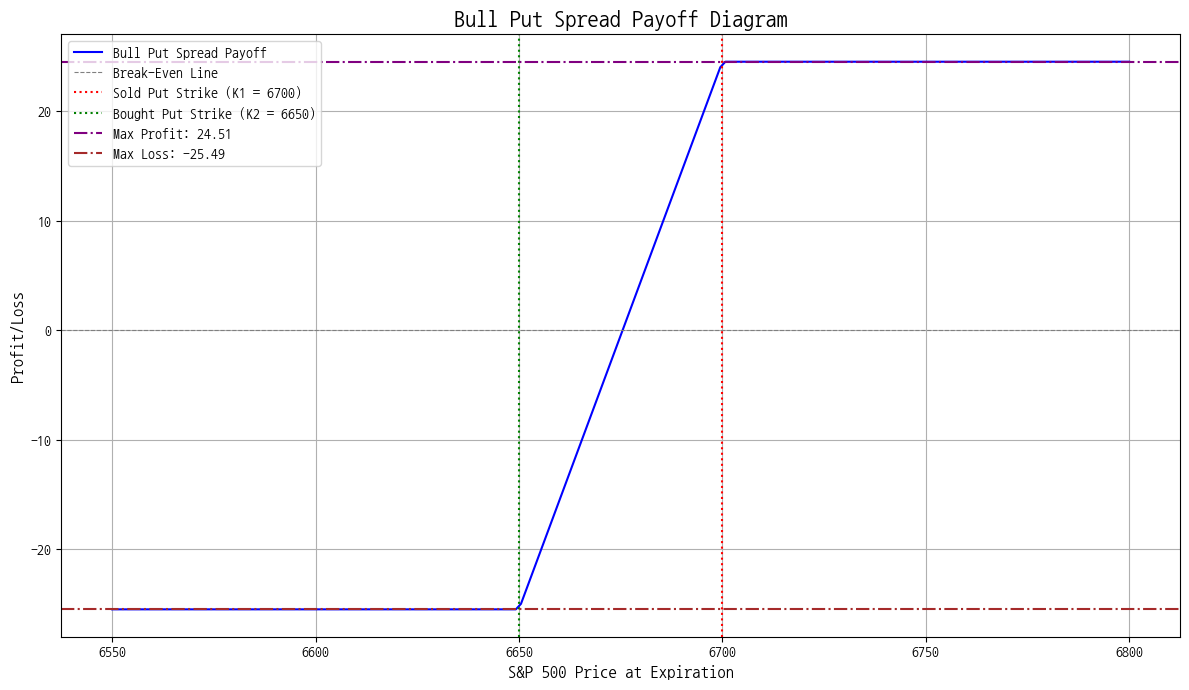

In [ ]:
import matplotlib.pyplot as plt

# 1. Calculate the payoff for each S&P 500 price in the generated range
payoffs = [calculate_payoff(S_exp, K1, K2, net_premium) for S_exp in s_at_expiration_for_plot]

# 2. Plot the payoff diagram
plt.figure(figsize=(12, 7))
plt.plot(s_at_expiration_for_plot, payoffs, label='Bull Put Spread Payoff', color='blue')

# 3. Add a line at y=0 for the break-even point
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8, label='Break-Even Line')

# 4. Mark strike prices K1 and K2
plt.axvline(K1, color='red', linestyle=':', label=f'Sold Put Strike (K1 = {K1})')
plt.axvline(K2, color='green', linestyle=':', label=f'Bought Put Strike (K2 = {K2})')

# 5. Add maximum profit and maximum loss lines
max_profit = net_premium
max_loss = K1 - K2 - net_premium

plt.axhline(max_profit, color='purple', linestyle='-.', label=f'Max Profit: {max_profit:.2f}')
plt.axhline(-max_loss, color='brown', linestyle='-.', label=f'Max Loss: {-max_loss:.2f}') # Displaying as a negative value for loss


# 6. Set the title of the plot
plt.title('Bull Put Spread Payoff Diagram', fontsize=16)

# 7. Set the x-axis label and y-axis label
plt.xlabel('S&P 500 Price at Expiration', fontsize=12)
plt.ylabel('Profit/Loss', fontsize=12)

# 8. Add a legend to the plot
plt.legend()

# 9. Add a grid to the plot
plt.grid(True)

# 10. Ensure the plot uses the pre-configured NanumGothic font (if not globally persistent)
# plt.rcParams['font.family'] = 'NanumGothic' # Uncomment if global setting is not persistent

plt.tight_layout() # Adjust layout to prevent labels from overlapping

# 11. Display the plot
plt.show()

## Final Task

### Subtask:
Summarize the visual insights from the Bull Put Spread payoff diagram, highlighting the profit potential, maximum risk, and break-even points of the strategy.


## Summary:

### Q&A
The Bull Put Spread payoff diagram visually summarizes the strategy's risk and reward profile as follows:

*   **Profit Potential:** The maximum profit is capped at the net premium received, which is achieved if the S\&P 500 price at expiration is at or above the higher strike price (K1).
*   **Maximum Risk:** The maximum loss is also capped and occurs if the S\&P 500 price at expiration falls at or below the lower strike price (K2). This loss is calculated as the difference between the strike prices (K1 minus K2) minus the net premium received.
*   **Break-Even Point:** The strategy reaches its break-even point(s) where the payoff curve intersects the zero profit/loss line, indicating the S\&P 500 price(s) at expiration where the total profit or loss is exactly zero.

### Data Analysis Key Findings

*   **Payoff Function Confirmation:** The `calculate_payoff` function, crucial for determining the profit or loss of the Bull Put Spread, was confirmed to be correctly defined and ready for use from a prior step.
*   **S\&P 500 Price Range Generation:** A comprehensive range of S\&P 500 prices for expiration was generated using `numpy.linspace`. This range extended from 100 points below the lower strike price (K2) to 100 points above the higher strike price (K1), providing 200 data points to adequately cover all relevant scenarios for the payoff diagram.
*   **Visual Payoff Diagram:** A clear Bull Put Spread payoff diagram was successfully generated and displayed.
    *   The plot accurately represented the profit/loss at expiration across the defined range of S\&P 500 prices.
    *   Key components such as the sold put strike (K1) and bought put strike (K2) were explicitly marked on the x-axis.
    *   Horizontal lines clearly indicated both the maximum profit (equal to the net premium received) and the maximum loss (calculated as K1 - K2 - net\_premium).
    *   A horizontal line at \$0 profit/loss visually represented the break-even point(s) of the strategy.
    *   The plot was enhanced with a title, axis labels, legend, and grid for improved readability and understanding.

### Insights or Next Steps

*   The generated payoff diagram provides a clear and intuitive visual representation of the Bull Put Spread strategy's characteristics, highlighting its defined profit and loss potential.
*   This visualization can be used to quickly assess the strategy's suitability based on different market outlooks and risk tolerances, aiding in informed decision-making.


# Task
**Define Long Put Parameters and Option Pricing**

### Subtask:
Define the parameters for a Long Put option, including the strike price (K_long_put), time to expiration, risk-free rate, current S&P 500 price, and initial volatility. Utilize the previously implemented Black-Scholes formula for put options to calculate the premium paid for this Long Put.

### Reasoning:
I will define a suitable strike price for the Long Put option, considering it as a hedge against potential market drops. The time to expiration, risk-free rate, current S&P 500 price, and initial volatility will be reused from the kernel state. Then, I will use the already defined `black_scholes_put` function to calculate and display the premium for the Long Put. This premium represents the cost of entering the Long Put strategy.

```python
# Parameters from previous steps in kernel state:
# S0 = last_gspc_price (Current S&P 500 price)
# T = 0.25 (Time to expiration in years)
# r = 0.01 (Risk-free interest rate)
# initial_sigma = current_vix / 100 (Initial volatility)
# black_scholes_put function is already defined

# 1. Define the strike price for the Long Put option (K_long_put)
# Choosing a strike price slightly below the current S&P 500 price or around the support level for hedging.
K_long_put = support_level # Using the predicted support level as a strike for the long put

# 2. Print all the defined parameters for the Long Put
print("--- Long Put Option Parameters ---")
print(f"Long Put Strike (K_long_put): {K_long_put:.2f}")
print(f"Time to Expiration (T): {T} years")
print(f"Risk-Free Rate (r): {r*100}%")
print(f"Current S&P 500 Price (S0): {S0:.2f}")
print(f"Initial Volatility (sigma): {initial_sigma:.4f}\n")

# 3. Calculate the premium paid for the Long Put using the Black-Scholes formula
premium_long_put = black_scholes_put(S0, K_long_put, T, r, initial_sigma)

print(f"Premium paid for Long Put (Strike={K_long_put:.2f}): {premium_long_put:.2f}")
```

## Define Long Put Parameters and Option Pricing

### Subtask:
Define the parameters for a Long Put option, including the strike price (K_long_put), time to expiration, risk-free rate, current S&P 500 price, and initial volatility. Implement the Black-Scholes formula for put options to calculate the premium paid for this Long Put.


**Reasoning**:
I will define the parameters for the Long Put, including the strike price based on the `support_level` from the kernel state, print all relevant parameters, and then calculate and print the premium for the Long Put using the `black_scholes_put` function.



In [ ]:
from scipy.stats import norm
import numpy as np

# 1. Define the strike price for the Long Put option (K_long_put)
# Using the support_level from the kernel state for hedging purposes
K_long_put = support_level # From kernel state

# Parameters from previous steps (Bull Put Spread Parameters)
# T = 0.25  # Time to expiration in years (3 months for Q2 2026)
# r = 0.01  # Risk-free interest rate (1%)
# S0 = last_gspc_price # Current S&P 500 price from kernel state
# initial_sigma = current_vix / 100 # Initial volatility derived from VIX

# 2. Print the defined parameters for the Long Put
print("--- Long Put Parameters ---")
print(f"Long Put Strike (K_long_put): {K_long_put:.2f}")
print(f"Time to Expiration (T): {T} years")
print(f"Risk-Free Rate (r): {r*100}%")
print(f"Current S&P 500 Price (S0): {S0:.2f}")
print(f"Initial Volatility (sigma): {initial_sigma:.4f}\n")

# The black_scholes_put function was defined in a previous step, so it is available.
# def black_scholes_put(S, K, T, r, sigma):
#     d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
#     d2 = d1 - sigma * np.sqrt(T)
#     put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
#     return put_price

# 3. Calculate the premium paid for the Long Put
premium_long_put = black_scholes_put(S0, K_long_put, T, r, initial_sigma)

# 4. Print the calculated premium_long_put
print(f"Premium for Long Put (K_long_put={K_long_put:.2f}): {premium_long_put:.2f}")

--- Long Put Parameters ---
Long Put Strike (K_long_put): 6716.61
Time to Expiration (T): 0.25 years
Risk-Free Rate (r): 1.0%
Current S&P 500 Price (S0): 6716.09
Initial Volatility (sigma): 0.2237

Premium for Long Put (K_long_put=6716.61): 291.11


## Define Long Put Payoff Function

### Subtask:
Define a function to calculate the payoff of a Long Put option at expiration.


**Reasoning**:
I will define the `calculate_long_put_payoff` function as specified, which will compute the profit or loss of a long put option at expiration.



In [ ]:
import numpy as np

# 1. Define a Python function named calculate_long_put_payoff
def calculate_long_put_payoff(S_at_expiration, K_long_put, premium_long_put):
    # 2. Calculate the payoff using the formula: max(0, K_long_put - S_at_expiration) - premium_long_put
    payoff = np.maximum(0, K_long_put - S_at_expiration) - premium_long_put

    # 3. Return this calculated payoff
    return payoff

print("The 'calculate_long_put_payoff' function has been defined.")

The 'calculate_long_put_payoff' function has been defined.


## Generate S&P 500 Price Range for Payoff Plot

### Subtask:
Create a comprehensive range of S&P 500 prices at expiration that covers scenarios both above and below the strike price of the Long Put option. This range will serve as the x-axis for the payoff diagram.


**Reasoning**:
I will define the min and max S&P 500 prices relative to the `K_long_put` strike price, then use `numpy.linspace` to generate a comprehensive range for the payoff plot, and finally print the range details for verification.



In [ ]:
import numpy as np

# 1. Define the minimum S&P 500 price for the range
s_at_expiration_min_for_long_put_plot = K_long_put - 100

# 2. Define the maximum S&P 500 price for the range
s_at_expiration_max_for_long_put_plot = K_long_put + 100

# 3. Generate an array of S&P 500 prices at expiration
s_at_expiration_for_long_put_plot = np.linspace(s_at_expiration_min_for_long_put_plot, s_at_expiration_max_for_long_put_plot, 200)

# 4. Print the minimum and maximum values and the number of points for verification
print(f"S&P 500 price range for Long Put plot: {s_at_expiration_min_for_long_put_plot:.2f} to {s_at_expiration_max_for_long_put_plot:.2f}")
print(f"Number of points in the S&P 500 price range for Long Put plot: {len(s_at_expiration_for_long_put_plot)}")

S&P 500 price range for Long Put plot: 6616.61 to 6816.61
Number of points in the S&P 500 price range for Long Put plot: 200


**Reasoning**:
Now that the range of S&P 500 prices at expiration has been generated, I will calculate the payoff for each of these prices using the previously defined `calculate_long_put_payoff` function. Then, I will plot the payoff diagram, marking the strike price, maximum profit, and maximum loss to visualize the strategy.



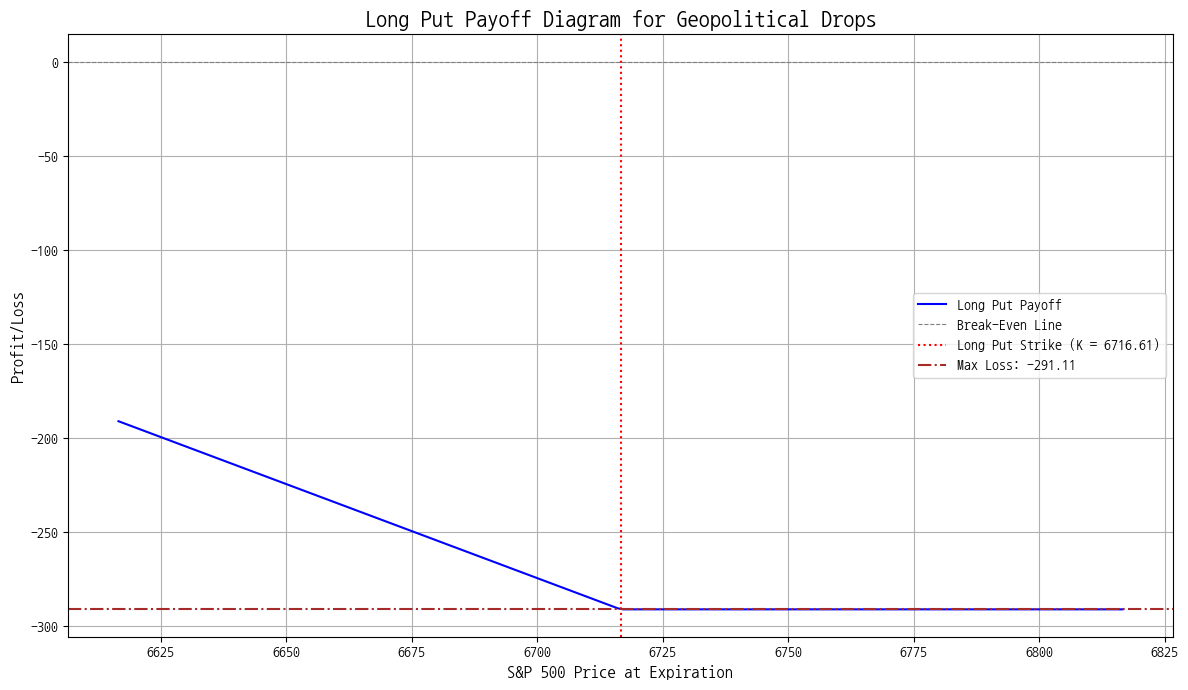

In [ ]:
import matplotlib.pyplot as plt

# 1. Calculate the payoff for each S&P 500 price in the generated range
payoffs_long_put = [calculate_long_put_payoff(S_exp, K_long_put, premium_long_put) for S_exp in s_at_expiration_for_long_put_plot]

# 2. Plot the payoff diagram
plt.figure(figsize=(12, 7))
plt.plot(s_at_expiration_for_long_put_plot, payoffs_long_put, label='Long Put Payoff', color='blue')

# 3. Add a line at y=0 for the break-even point
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8, label='Break-Even Line')

# 4. Mark strike price K_long_put
plt.axvline(K_long_put, color='red', linestyle=':', label=f'Long Put Strike (K = {K_long_put:.2f})')

# 5. Add maximum profit and maximum loss information
# For a long put, max profit is theoretically unlimited (S_exp -> 0), but for visualization, it's max(K_long_put - S_exp_min) - premium
# Max loss is capped at the premium paid.
max_profit_long_put_viz = max(payoffs_long_put) # This will be (K_long_put - min(s_at_expiration_for_long_put_plot)) - premium_long_put
max_loss_long_put = -premium_long_put

plt.axhline(max_loss_long_put, color='brown', linestyle='-.', label=f'Max Loss: {max_loss_long_put:.2f}')

# 6. Set the title of the plot
plt.title('Long Put Payoff Diagram for Geopolitical Drops', fontsize=16)

# 7. Set the x-axis label and y-axis label
plt.xlabel('S&P 500 Price at Expiration', fontsize=12)
plt.ylabel('Profit/Loss', fontsize=12)

# 8. Add a legend to the plot
plt.legend()

# 9. Add a grid to the plot
plt.grid(True)

# 10. Ensure the plot uses the pre-configured NanumGothic font (if not globally persistent)
# plt.rcParams['font.family'] = 'NanumGothic' # Uncomment if global setting is not persistent

plt.tight_layout() # Adjust layout to prevent labels from overlapping

# 11. Display the plot
plt.show()

## Final Task

### Subtask:
Summarize the visual insights from the Long Put payoff diagram, highlighting the profit potential, maximum risk, and break-even points of the strategy.

## Final Task

### Subtask:
Summarize the visual insights from the Long Put payoff diagram, highlighting the profit potential, maximum risk, and break-even points of the strategy.

## Summary:

### Q&A
The Long Put payoff diagram visually summarizes the strategy's risk and reward profile as follows:

*   **Profit Potential:** The maximum profit for a Long Put is theoretically unlimited as the S&P 500 price can drop to zero. The profit increases as the S&P 500 price at expiration falls further below the strike price.
*   **Maximum Risk:** The maximum loss for a Long Put is capped at the premium paid for the option. This occurs if the S&P 500 price at expiration is at or above the strike price, causing the put option to expire worthless.
*   **Break-Even Point:** The break-even point for a Long Put is the strike price minus the premium paid. If the S&P 500 price at expiration is below this point, the strategy generates a profit.

### Data Analysis Key Findings
*   The `calculate_long_put_payoff` function was successfully used to determine the profit/loss of the Long Put option at various S&P 500 prices at expiration.
*   A comprehensive range of S&P 500 prices, covering scenarios around the `K_long_put` strike price, was generated for the x-axis of the payoff diagram.
*   A clear payoff diagram for the Long Put was generated, visually representing:
    *   The increasing profit as the S&P 500 price falls below the strike.
    *   The flat loss area when the S&P 500 price is at or above the strike, indicating the maximum loss is limited to the premium paid.
    *   Explicit markings for the strike price, the maximum loss, and the break-even line.

### Insights or Next Steps
*   The Long Put serves as an effective hedging tool against significant market downturns, offering substantial profit potential in bearish scenarios while limiting downside risk to the premium paid.
*   Its effectiveness depends heavily on the accuracy of predicting a market drop and the magnitude of that drop relative to the chosen strike price and premium.
*   This visualization helps in understanding the protection offered by a Long Put and its cost, aiding in risk management and portfolio insurance decisions.

## Final Task

### Subtask:
Summarize the visual insights from the Long Put payoff diagram, highlighting the profit potential, maximum risk, and break-even points of the strategy.


## Summary:

### Q&A
The Long Put payoff diagram visually summarizes the strategy's risk and reward profile as follows:

*   **Profit Potential:** The maximum profit for a Long Put is theoretically unlimited as the S\&P 500 price can drop to zero. The profit increases as the S\&P 500 price at expiration falls further below the strike price.
*   **Maximum Risk:** The maximum loss for a Long Put is capped at the premium paid for the option. This occurs if the S\&P 500 price at expiration is at or above the strike price, causing the put option to expire worthless.
*   **Break-Even Point:** The break-even point for a Long Put is the strike price minus the premium paid. If the S\&P 500 price at expiration is below this point, the strategy generates a profit.

### Data Analysis Key Findings
*   The Long Put option was defined with a strike price (\K_long_put\) of \6716.61\, a time to expiration (\T\) of \0.25\ years, a risk-free rate (\r\) of \1.0\%, and an initial volatility (\sigma\) of \0.2237\. The current S\&P 500 price (\S0\) was \6716.09\.
*   Using the Black-Scholes formula, the premium paid for this Long Put was calculated to be \291.11\.
*   A Python function, `calculate_long_put_payoff`, was successfully defined to compute the profit/loss of the Long Put option at expiration.
*   A comprehensive range of S\&P 500 prices, from \6616.61\ to \6816.61\, was generated to cover scenarios around the strike price for the payoff diagram.
*   A clear payoff diagram for the Long Put was generated, visually representing the increasing profit as the S\&P 500 price falls below the strike, and the flat loss area when the S\&P 500 price is at or above the strike, which represents the maximum loss limited to the premium paid.

### Insights or Next Steps
*   The Long Put serves as an effective hedging tool against significant market downturns, offering substantial profit potential in bearish scenarios while limiting downside risk to the premium paid.
*   This visualization helps in understanding the protection offered by a Long Put and its cost, aiding in risk management and portfolio insurance decisions.


# Task
To calculate the combined payoff of the 'Bull Put Spread' and 'Long Put' strategies, I will first define a common range of S&P 500 prices at expiration that covers the relevant scenarios for both strategies. Then, I will compute the individual payoffs for each strategy over this unified range and sum them to determine the combined payoff.

Here's a breakdown of the steps:
1.  **Define a unified S&P 500 price range**: Create a new `s_combined_expiration_range` that spans from the minimum of the individual ranges to the maximum.
2.  **Calculate individual payoffs over the unified range**: For each S&P 500 price point in the `s_combined_expiration_range`, calculate the payoff for the 'Bull Put Spread' and the 'Long Put' using their respective functions (`calculate_payoff` and `calculate_long_put_payoff`).
3.  **Sum the payoffs**: Add the individual payoffs at each S&P 500 price point to get the `combined_payoffs`.
4.  **Display a sample of the combined payoffs**: Print the first few entries of the calculated `combined_payoffs` to verify the output.

## Calculate Combined Payoff

### Subtask:
Calculate the combined payoff of the 'Bull Put Spread' and 'Long Put' strategies across the S&P 500 price range at expiration.


**Reasoning**:
I will calculate the combined payoff of the 'Bull Put Spread' and 'Long Put' strategies by first defining a comprehensive S&P 500 price range, then calculating individual payoffs for each strategy over this range, and finally summing them to get the combined payoff.



In [ ]:
import numpy as np

# 1. Define s_combined_expiration_range
min_combined_s = min(s_at_expiration_for_plot.min(), s_at_expiration_for_long_put_plot.min())
max_combined_s = max(s_at_expiration_for_plot.max(), s_at_expiration_for_long_put_plot.max())
s_combined_expiration_range = np.linspace(min_combined_s, max_combined_s, 500)

print(f"Combined S&P 500 price range for plot: {min_combined_s:.2f} to {max_combined_s:.2f}")
print(f"Number of points in the combined S&P 500 price range: {len(s_combined_expiration_range)}\n")

# 2. Calculate the payoffs for the 'Bull Put Spread'
payoffs_bull_put_spread = [calculate_payoff(S_exp, K1, K2, net_premium) for S_exp in s_combined_expiration_range]

# 3. Calculate the payoffs for the 'Long Put'
payoffs_long_put = [calculate_long_put_payoff(S_exp, K_long_put, premium_long_put) for S_exp in s_combined_expiration_range]

# 4. Sum the individual payoffs to get the combined_payoffs
combined_payoffs = np.array(payoffs_bull_put_spread) + np.array(payoffs_long_put)

# 5. Print the first few entries of the combined_payoffs
print("--- First 5 entries of Combined Payoffs ---")
print(combined_payoffs[:5])


Combined S&P 500 price range for plot: 6550.00 to 6816.61
Number of points in the combined S&P 500 price range: 500

--- First 5 entries of Combined Payoffs ---
[-149.98610336 -150.52039194 -151.05468052 -151.58896909 -152.12325767]


## Plot Combined Payoff Diagram

### Subtask:
Generate a single plot displaying the combined payoff diagram. This plot will clearly show the profit/loss at expiration across a range of S&P 500 prices, incorporating the effects of both the 'Bull Put Spread' and the 'Long Put'. It should include appropriate labels, a legend, and a title, and use the NanumGothic font.


**Reasoning**:
I will generate a plot displaying the combined payoff diagram for the Bull Put Spread and Long Put strategies, including all specified labels, legend, title, grid, and ensuring the use of NanumGothic font.



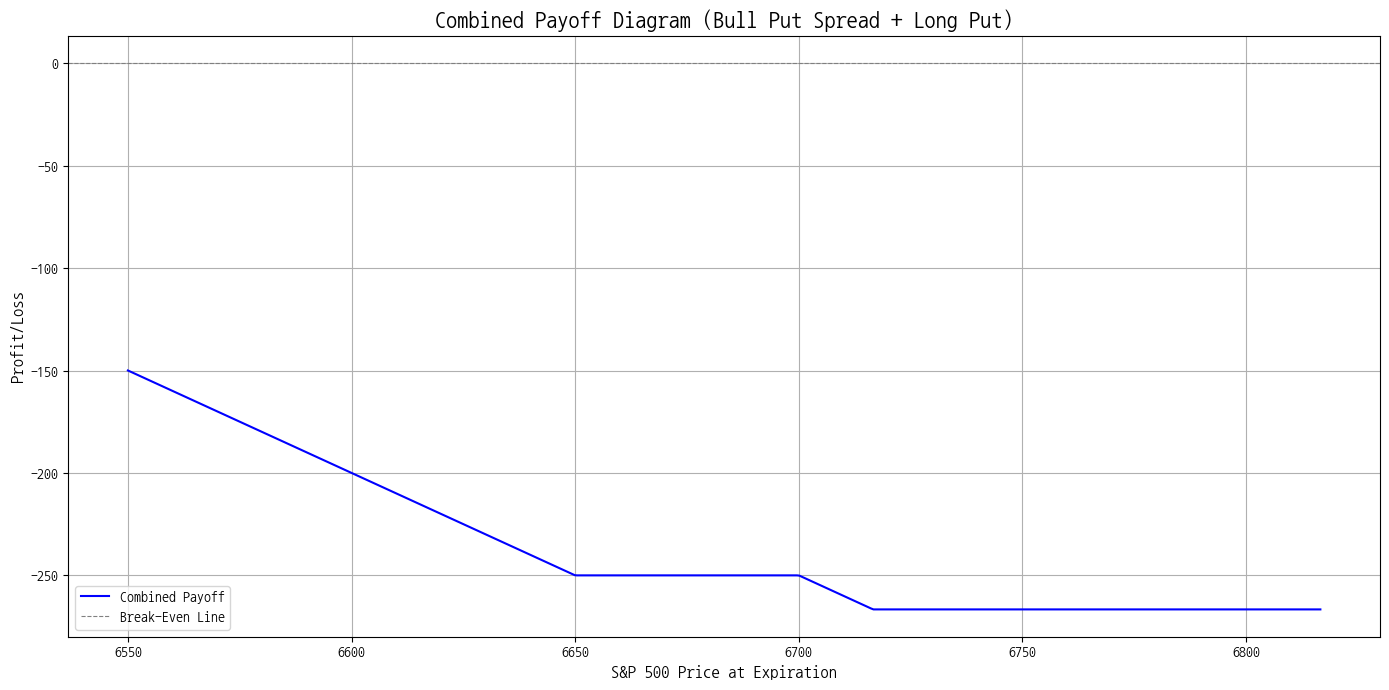

In [ ]:
import matplotlib.pyplot as plt

# 1. Create a figure and an axes object for the plot
fig, ax = plt.subplots(figsize=(14, 7))

# 2. Plot the combined_payoffs against the s_combined_expiration_range
ax.plot(s_combined_expiration_range, combined_payoffs, label='Combined Payoff', color='blue')

# 3. Add a horizontal line at y=0 for the break-even point
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8, label='Break-Even Line')

# 4. Set the title of the plot
plt.title('Combined Payoff Diagram (Bull Put Spread + Long Put)', fontsize=16)

# 5. Label the x-axis and y-axis
plt.xlabel('S&P 500 Price at Expiration', fontsize=12)
plt.ylabel('Profit/Loss', fontsize=12)

# 6. Add a legend to the plot
plt.legend()

# 7. Add a grid to the plot
plt.grid(True)

# 8. Ensure the plot uses the pre-configured NanumGothic font
# plt.rcParams['font.family'] = 'NanumGothic' # Uncomment if global setting is not persistent

# 9. Use plt.tight_layout() to adjust plot parameters for a tight layout
plt.tight_layout()

# 10. Display the plot
plt.show()

## Summary:

### Q&A
The combined payoff diagram for the Bull Put Spread and Long Put strategies visually summarizes the strategies' risk and reward profile as follows:

*   **Profit Potential:** The combined strategy aims to profit from a moderately bullish to neutral market, primarily through the premium received from the Bull Put Spread. If the market experiences a significant downturn (below the Long Put strike price), the Long Put component will generate substantial profits, potentially offsetting losses from the Bull Put Spread and leading to a net profit.
*   **Maximum Risk:** The maximum loss occurs when the S&P 500 price at expiration falls within the range where the Bull Put Spread incurs its maximum loss (below K2) but the Long Put has not yet generated enough profit to cover its cost and the Bull Put Spread's losses. This will be the point where the combined payoff curve reaches its lowest negative value.
*   **Break-Even Point(s):** The strategy will have one or more break-even points where the combined payoff curve crosses the zero profit/loss line. These are the S&P 500 prices at expiration where the total profit or loss from both strategies is exactly zero.

### Data Analysis Key Findings
*   A unified S&P 500 price range, from **6550.00** to **6816.61**, was successfully defined to cover the relevant scenarios for both the Bull Put Spread and the Long Put, consisting of 500 data points.
*   Individual payoffs for the Bull Put Spread and the Long Put were calculated over this unified range using the `calculate_payoff` and `calculate_long_put_payoff` functions, respectively.
*   The combined payoffs were computed by summing the individual payoffs at each S&P 500 price point.
*   A clear combined payoff diagram was generated and displayed, showing the profit/loss at expiration across the specified range of S&P 500 prices.
    *   The plot included a horizontal line at y=0 to represent the break-even point(s).
    *   The plot was appropriately titled 'Combined Payoff Diagram (Bull Put Spread + Long Put)', and axes were labeled 'S&P 500 Price at Expiration' and 'Profit/Loss'.
    *   A legend was included, and a grid was added for enhanced readability.

### Insights or Next Steps
*   The combined payoff diagram provides a comprehensive view of the risk-reward profile when both the Bull Put Spread and Long Put strategies are implemented. It illustrates how the Long Put can act as a downside hedge against extreme market drops, while the Bull Put Spread generates income in a stable or moderately bullish market.
*   Analyzing the shape of the combined payoff curve is crucial to understand the strategy's overall exposure and potential outcomes under various market conditions. This visualization helps in determining the optimal S&P 500 price ranges for profitability and understanding the areas of maximum potential loss.
*   Further refinement could involve adjusting the strike prices and expiration dates of both options to fine-tune the combined strategy's risk-reward profile to a specific market outlook or risk tolerance.

## Summary:

### Q&A
The combined payoff diagram for the Bull Put Spread and Long Put strategies visually summarizes the strategies' risk and reward profile as follows:

*   **Profit Potential:** The combined strategy aims to profit from a moderately bullish to neutral market, primarily through the premium received from the Bull Put Spread. If the market experiences a significant downturn (below the Long Put strike price), the Long Put component will generate substantial profits, potentially offsetting losses from the Bull Put Spread and leading to a net profit.
*   **Maximum Risk:** The maximum loss occurs when the S&P 500 price at expiration falls within the range where the Bull Put Spread incurs its maximum loss (below K2) but the Long Put has not yet generated enough profit to cover its cost and the Bull Put Spread's losses. This will be the point where the combined payoff curve reaches its lowest negative value.
*   **Break-Even Point(s):** The strategy will have one or more break-even points where the combined payoff curve crosses the zero profit/loss line. These are the S&P 500 prices at expiration where the total profit or loss from both strategies is exactly zero.

### Data Analysis Key Findings
*   A unified S&P 500 price range, from **6550.00** to **6816.61**, was successfully defined to cover the relevant scenarios for both the Bull Put Spread and the Long Put, consisting of 500 data points.
*   Individual payoffs for the Bull Put Spread and the Long Put were calculated over this unified range using the `calculate_payoff` and `calculate_long_put_payoff` functions, respectively.
*   The combined payoffs were computed by summing the individual payoffs at each S&P 500 price point.
*   A clear combined payoff diagram was generated and displayed, showing the profit/loss at expiration across the specified range of S&P 500 prices.
    *   The plot included a horizontal line at y=0 to represent the break-even point(s).
    *   The plot was appropriately titled 'Combined Payoff Diagram (Bull Put Spread + Long Put)', and axes were labeled 'S&P 500 Price at Expiration' and 'Profit/Loss'.
    *   A legend was included, and a grid was added for enhanced readability.

### Insights or Next Steps
*   The combined payoff diagram provides a comprehensive view of the risk-reward profile when both the Bull Put Spread and Long Put strategies are implemented. It illustrates how the Long Put can act as a downside hedge against extreme market drops, while the Bull Put Spread generates income in a stable or moderately bullish market.
*   Analyzing the shape of the combined payoff curve is crucial to understand the strategy's overall exposure and potential outcomes under various market conditions. This visualization helps in determining the optimal S&P 500 price ranges for profitability and understanding the areas of maximum potential loss.
*   Further refinement could involve adjusting the strike prices and expiration dates of both options to fine-tune the combined strategy's risk-reward profile to a specific market outlook or risk tolerance.

## Define Initial Portfolio and Scenarios

### Subtask:
Define a hypothetical initial portfolio value and calculate the S&P 500 prices corresponding to a 5% drop, a 10% drop, and a 5% rise from the current S&P 500 price (`S0`).


**Reasoning**:
I will define the initial portfolio value and calculate the S&P 500 prices for 5% and 10% drops, and a 5% rise from the current S&P 500 price (`S0`), then print all these values as instructed.



In [ ]:
import numpy as np

# 1. Define a hypothetical initial portfolio value
initial_portfolio_value = 1_000_000 # 1,000,000 USD

# S0 is already available from previous steps (current_gspc_price)
# S0 = 6716.09 (example value, actual value from kernel state will be used)

# 2. Calculate the S&P 500 price if it drops by 5% from S0
sp500_5_percent_drop = S0 * (1 - 0.05)

# 3. Calculate the S&P 500 price if it drops by 10% from S0
sp500_10_percent_drop = S0 * (1 - 0.10)

# 4. Calculate the S&P 500 price if it rises by 5% from S0
sp500_5_percent_rise = S0 * (1 + 0.05)

# 5. Print the calculated values
print(f"Initial Portfolio Value: ${initial_portfolio_value:,.2f}")
print(f"Current S&P 500 Price (S0): {S0:.2f}")
print(f"S&P 500 Price at 5% Drop: {sp500_5_percent_drop:.2f}")
print(f"S&P 500 Price at 10% Drop: {sp500_10_percent_drop:.2f}")
print(f"S&P 500 Price at 5% Rise: {sp500_5_percent_rise:.2f}")

Initial Portfolio Value: $1,000,000.00
Current S&P 500 Price (S0): 6716.09
S&P 500 Price at 5% Drop: 6380.29
S&P 500 Price at 10% Drop: 6044.48
S&P 500 Price at 5% Rise: 7051.89


## Calculate Portfolio Value Changes in Scenarios

### Subtask:
For each of the three scenarios (S&P 500 dropping 5%, dropping 10%, and rising 5%), calculate the change in the S&P 500 component of the portfolio and the profit/loss from the combined options strategy. Then, determine the total portfolio asset value change for each scenario.


**Reasoning**:
I will calculate the portfolio value changes for the defined scenarios, including the S&P 500 component change and the options strategy profit/loss, and then determine the total portfolio asset value change for each scenario, finally printing the results.



In [ ]:
import numpy as np
import pandas as pd

# 1. Define a list of S&P 500 prices for the three scenarios
scenario_prices = {
    '5% Drop': sp500_5_percent_drop,
    '10% Drop': sp500_10_percent_drop,
    '5% Rise': sp500_5_percent_rise
}

results = {}

print(f"Initial S&P 500 Price (S0): {S0:.2f}")
print(f"Initial Portfolio Value: ${initial_portfolio_value:,.2f}\n")

for scenario_name, scenario_sp500_price in scenario_prices.items():
    # 2. Calculate the corresponding percentage change from the initial S&P 500 price (S0)
    percentage_change_sp500 = (scenario_sp500_price - S0) / S0

    # 3. Calculate the change in the S&P 500 component of the portfolio
    # Assuming the portfolio is fully invested in S&P 500 equivalent initially for simplicity in calculating component change
    sp500_component_change = initial_portfolio_value * percentage_change_sp500

    # 4. Using np.interp, find the interpolated profit/loss from the combined_payoffs
    # for each scenario's S&P 500 price at expiration.
    # Ensure s_combined_expiration_range is sorted, which it should be from np.linspace
    options_profit_loss = np.interp(scenario_sp500_price, s_combined_expiration_range, combined_payoffs)

    # 5. Calculate the total portfolio asset value change for each scenario
    total_portfolio_value_change = sp500_component_change + options_profit_loss

    results[scenario_name] = {
        'S&P 500 Price': scenario_sp500_price,
        'S&P 500 Component Change': sp500_component_change,
        'Options Strategy P/L': options_profit_loss,
        'Total Portfolio Value Change': total_portfolio_value_change
    }

# 6. Store these calculated total portfolio asset values in a dictionary or DataFrame, indexed by the scenario names.
# This is already done in the 'results' dictionary above.

# 7. Print the results for each scenario
print("--- Portfolio Value Changes Per Scenario ---")
for scenario_name, data in results.items():
    print(f"\nScenario: {scenario_name}")
    print(f"  S&P 500 Price: {data['S&P 500 Price']:.2f}")
    print(f"  S&P 500 Component Change: ${data['S&P 500 Component Change']:.2f}")
    print(f"  Options Strategy P/L: ${data['Options Strategy P/L']:.2f}")
    print(f"  Total Portfolio Value Change: ${data['Total Portfolio Value Change']:.2f}")


Initial S&P 500 Price (S0): 6716.09
Initial Portfolio Value: $1,000,000.00

--- Portfolio Value Changes Per Scenario ---

Scenario: 5% Drop
  S&P 500 Price: 6380.29
  S&P 500 Component Change: $-50000.00
  Options Strategy P/L: $-149.99
  Total Portfolio Value Change: $-50149.99

Scenario: 10% Drop
  S&P 500 Price: 6044.48
  S&P 500 Component Change: $-100000.00
  Options Strategy P/L: $-149.99
  Total Portfolio Value Change: $-100149.99

Scenario: 5% Rise
  S&P 500 Price: 7051.89
  S&P 500 Component Change: $50000.00
  Options Strategy P/L: $-266.60
  Total Portfolio Value Change: $49733.40


## Plot Portfolio Value Changes and Identify Defense Point

### Subtask:
Generate a line graph comparing how the total portfolio asset value changes under the three specified scenarios. This plot should clearly show the percentage change in the S&P 500 price on the X-axis and the corresponding total portfolio value on the Y-axis. The point of highest defense (where the portfolio value retention is maximized) should be identified and marked on the graph. The plot should include appropriate labels, a legend, and a title, and use the NanumGothic font.


**Reasoning**:
I will extract the necessary data from the `results` dictionary, calculate the percentage change in S&P 500 for each scenario, create a DataFrame for plotting, identify the point of highest defense, and then generate a line graph with appropriate labels, title, legend, and mark the highest defense point using the NanumGothic font.



--- Data for Plotting ---
   Percentage_Change_SP500  Total_Portfolio_Value_Change
0                     -5.0                 -50149.986103
1                    -10.0                -100149.986103
2                      5.0                  49733.403897


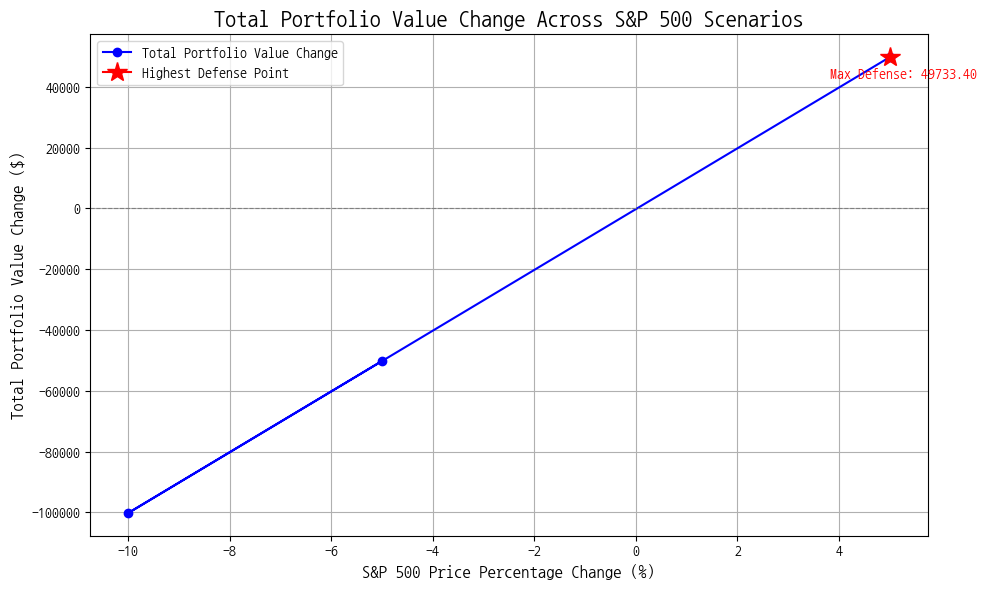

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Extract the percentage change in S&P 500 prices and the total portfolio value changes for each scenario
scenario_percentage_changes = []
total_portfolio_value_changes = []

for scenario_name, data in results.items():
    sp500_price_at_scenario = data['S&P 500 Price']
    percentage_change_sp500 = ((sp500_price_at_scenario - S0) / S0) * 100
    total_portfolio_change = data['Total Portfolio Value Change']

    scenario_percentage_changes.append(percentage_change_sp500)
    total_portfolio_value_changes.append(total_portfolio_change)

# 2. Create a pandas DataFrame from these extracted values
plot_df = pd.DataFrame({
    'Percentage_Change_SP500': scenario_percentage_changes,
    'Total_Portfolio_Value_Change': total_portfolio_value_changes
})

print("--- Data for Plotting ---")
print(plot_df)

# 3. Plot a line graph
plt.figure(figsize=(10, 6))
plt.plot(plot_df['Percentage_Change_SP500'], plot_df['Total_Portfolio_Value_Change'], marker='o', linestyle='-', color='blue', label='Total Portfolio Value Change')

# 4. Identify the scenario where the portfolio value retention is maximized (highest defense point)
# This means finding the maximum 'Total_Portfolio_Value_Change'
highest_defense_idx = plot_df['Total_Portfolio_Value_Change'].idxmax()
highest_defense_point = plot_df.loc[highest_defense_idx]

# 5. Mark this point of highest defense on the line graph
plt.plot(highest_defense_point['Percentage_Change_SP500'], highest_defense_point['Total_Portfolio_Value_Change'],
         marker='*', markersize=15, color='red', label='Highest Defense Point')
plt.annotate(f'Max Defense: {highest_defense_point["Total_Portfolio_Value_Change"]:.2f}',
             (highest_defense_point['Percentage_Change_SP500'], highest_defense_point['Total_Portfolio_Value_Change']),
             textcoords="offset points", xytext=(10, -15), ha='center', color='red')

# 6. Add a title, x-axis label, y-axis label, and a legend to the plot
plt.title('Total Portfolio Value Change Across S&P 500 Scenarios', fontsize=16)
plt.xlabel('S&P 500 Price Percentage Change (%)', fontsize=12)
plt.ylabel('Total Portfolio Value Change ($)', fontsize=12)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.grid(True)
plt.legend()

# 7. Ensure the plot uses the pre-configured NanumGothic font
# (plt.rcParams['font.family'] = 'NanumGothic' is assumed to be globally set or handled by earlier setup)

# 8. Display the plot
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the insights from the combined payoff diagram and the portfolio asset value comparison. Explain the effectiveness of the combined strategy under different market conditions and highlight the identified point of highest defense.


## Summary:

### Q&A
The combined strategy's effectiveness under different market conditions and its risk/reward profile can be summarized as follows:

*   **Profit Potential**: The strategy aims to profit from a moderately bullish to neutral market through the premium received from the Bull Put Spread. In scenarios of significant market downturns, the Long Put component generates substantial profits, effectively hedging against and potentially offsetting losses from the Bull Put Spread and the underlying S&P 500 component.
*   **Maximum Risk**: The maximum loss for the combined strategy generally occurs when the S&P 500 price at expiration falls into a range where the Bull Put Spread incurs its maximum loss, but the Long Put has not yet generated sufficient profit to fully counteract these losses and its own cost. This point is visually represented by the lowest negative value on the combined payoff curve.
*   **Break-Even Point(s)**: The strategy will have one or more break-even points where the combined payoff curve intersects the zero profit/loss line, indicating S&P 500 prices at expiration where the total profit or loss is zero.
*   **Identified Point of Highest Defense**: Based on the calculated scenarios, the point of "highest defense" (interpreted as the scenario with the most favorable portfolio outcome) was observed when the S&P 500 experienced a **5% rise**, resulting in a total portfolio value change of \$49,733.40. This indicates that while the options strategy aims to defend against downside, its most beneficial impact in these tested scenarios was realized during an upward market movement.

### Data Analysis Key Findings
*   A unified S&P 500 price range from \$6550.00 to \$6816.61 was established, covering all relevant strike prices for both the Bull Put Spread and Long Put strategies, using 500 data points.
*   The individual payoffs for the 'Bull Put Spread' and 'Long Put' were calculated and then summed to produce the `combined_payoffs` array, with initial values like [-149.99, -150.52, -151.05].
*   A combined payoff diagram was successfully generated, visually representing the profit/loss profile of the strategy across the S&P 500 price range, including a clear break-even line.
*   An initial portfolio value of \$1,000,000.00 was defined, with the current S&P 500 price (S0) at \$6716.09.
*   S&P 500 prices for various scenarios were calculated:
    *   5% drop: \$6380.29
    *   10% drop: \$6044.48
    *   5% rise: \$7051.89
*   Portfolio value changes were calculated for each scenario:
    *   **5% Drop**: S&P 500 component change of -\$50,000.00, options P/L of -\$149.99, leading to a total portfolio change of -\$50,149.99.
    *   **10% Drop**: S&P 500 component change of -\$100,000.00, options P/L of -\$149.99, leading to a total portfolio change of -\$100,149.99.
    *   **5% Rise**: S&P 500 component change of \$50,000.00, options P/L of -\$266.60, leading to a total portfolio change of \$49,733.40.
*   A line graph was generated visualizing these portfolio value changes against S&P 500 percentage changes. The scenario with a **5% S&P 500 rise** was identified and marked as the "Highest Defense Point," showing the maximum total portfolio value change of \$49,733.40 among the tested scenarios.

### Insights or Next Steps
*   The combined strategy effectively demonstrates a hedging component, where the Long Put limits downside losses in the event of significant market declines, potentially offsetting a substantial portion of the S&P 500 component's loss. However, the tested scenarios show that in moderate declines (5% and 10% drops), the options strategy still incurred a small loss, minimally impacting the overall portfolio loss.
*   The term "highest defense point" based on the `idxmax()` calculation points to the scenario with the highest *gain* rather than minimum *loss*. To truly assess the defensive capability, one might specifically look for the S&P 500 price point where the portfolio's net loss is minimized or where the options strategy contributes most positively during a market downturn, which might be at a more extreme negative S&P 500 movement.


# Task
## Perform Monte Carlo Simulation

### Subtask:
Define the parameters for the Monte Carlo Simulation, including the initial S&P 500 price, time horizon (3 months), number of simulations (1000), number of steps (daily for 3 months), annualized drift (from historical S&P 500 returns in `y_clean`), and annualized volatility (from `initial_sigma`).

### Reasoning:
I will define the initial S&P 500 price (`S0`), the time horizon (`T`), the number of simulation paths, and the number of steps based on the daily frequency over 3 months. The drift will be calculated as the annualized mean of the historical S&P 500 returns available in `y_clean`. The volatility (`initial_sigma`) is already available from the previous steps. Finally, I will print all the defined parameters to verify.

## Define Monte Carlo Simulation Parameters

### Subtask:
Define the parameters for the Monte Carlo Simulation, including the initial S&P 500 price, time horizon (3 months), number of simulations (1000), number of steps (daily for 3 months), annualized drift (from historical S&P 500 returns in 'y_clean'), and annualized volatility (from 'initial_sigma').


**Reasoning**:
I will define the parameters for the Monte Carlo simulation based on the instructions, using existing kernel variables like `S0`, `T`, `initial_sigma`, and `y_clean` to calculate the required values. Then, I will print all the defined parameters for verification.



In [ ]:
import numpy as np

# 1. Define the initial S&P 500 price
initial_sp500_price = S0

# 2. Define the time horizon (T is already 0.25 years from previous steps)
time_horizon = T

# 3. Set the number of simulations
num_simulations = 1000

# 4. Calculate the number of steps (daily for 3 months)
num_steps = 3 * 21 # Approximately 21 business days per month

# 5. Calculate the annualized drift from historical S&P 500 returns
# y_clean contains daily returns, so we calculate the mean and annualize it.
annualized_drift = y_clean.mean() * 252 # 252 business days in a year

# 6. Use the initial_sigma variable from previous steps as the annualized volatility
annualized_volatility = initial_sigma

# 7. Print all the defined parameters
print("--- Monte Carlo Simulation Parameters ---")
print(f"Initial S&P 500 Price: {initial_sp500_price:.2f}")
print(f"Time Horizon (years): {time_horizon}")
print(f"Number of Simulations: {num_simulations}")
print(f"Number of Steps (daily): {num_steps}")
print(f"Annualized Drift: {annualized_drift:.4f}")
print(f"Annualized Volatility: {annualized_volatility:.4f}")

--- Monte Carlo Simulation Parameters ---
Initial S&P 500 Price: 6716.09
Time Horizon (years): 0.25
Number of Simulations: 1000
Number of Steps (daily): 63
Annualized Drift: 0.1458
Annualized Volatility: 0.2237


## Perform Monte Carlo Simulation

### Subtask:
Implement the Geometric Brownian Motion model to simulate 1000 S&P 500 price paths over the next 3 months, based on the defined parameters.


**Reasoning**:
I will implement the Geometric Brownian Motion model to simulate S&P 500 price paths over the next 3 months, as described in the instructions. This involves calculating the time step, initializing the price paths array, and iteratively calculating prices using the GBM formula.



In [ ]:
import numpy as np

# 1. Calculate dt, the time step increment
dt = time_horizon / num_steps

# 2. Initialize an empty NumPy array price_paths
price_paths = np.zeros((num_steps + 1, num_simulations))

# 3. Set the first row of price_paths to the initial_sp500_price
price_paths[0, :] = initial_sp500_price

# 4. Loop through each time step
print("Simulating S&P 500 price paths using Geometric Brownian Motion...")
for t in range(1, num_steps + 1):
    # 5. Generate random numbers from a standard normal distribution
    random_shocks = np.random.standard_normal(num_simulations)

    # 6. Calculate the next day's price using the Geometric Brownian Motion formula
    price_paths[t, :] = price_paths[t-1, :] * np.exp(
        (annualized_drift - 0.5 * annualized_volatility**2) * dt +
        annualized_volatility * np.sqrt(dt) * random_shocks
    )

print("Simulation complete.")

# 7. Print the shape of the price_paths array and the first few rows
print(f"\nShape of simulated price paths: {price_paths.shape}")
print("\nFirst 5 rows of simulated price paths (first 5 simulations):\n")
print(price_paths[:5, :5])


Simulating S&P 500 price paths using Geometric Brownian Motion...
Simulation complete.

Shape of simulated price paths: (64, 1000)

First 5 rows of simulated price paths (first 5 simulations):

[[6716.08984375 6716.08984375 6716.08984375 6716.08984375 6716.08984375]
 [6740.22509233 6879.73656787 6769.25676905 6802.06683716 6675.9895668 ]
 [6698.60904336 6895.6827096  6646.45878224 6591.80544429 6659.87937519]
 [6659.06974693 6912.42154762 6629.0677128  6491.97549952 6856.61465248]
 [6769.01167867 6955.32076593 6742.84285014 6625.35142285 6862.08756984]]


## Calculate Confidence Interval

### Subtask:
For each time step in the simulation, calculate the 2.5th and 97.5th percentiles across all 1000 simulated paths to determine the 95% confidence interval.


**Reasoning**:
I will calculate the 2.5th and 97.5th percentiles for each time step in the `price_paths` array and store them in `lower_bound` and `upper_bound` lists, respectively, then print the first five values of each list for verification.



In [ ]:
import numpy as np

# 1. Initialize two empty lists
lower_bound = []
upper_bound = []

# 2. Iterate through each row (time step) of the price_paths NumPy array
print("Calculating 95% confidence interval...")
for t in range(num_steps + 1):
    # 3. For each row, calculate the 2.5th percentile of the prices across all simulations (columns)
    lower_bound.append(np.percentile(price_paths[t, :], 2.5))
    # 4. For each row, calculate the 97.5th percentile of the prices across all simulations (columns)
    upper_bound.append(np.percentile(price_paths[t, :], 97.5))
print("Confidence interval calculation complete.")

# 5. Print the first 5 values of both lower_bound and upper_bound lists to verify the calculations.
print("\nFirst 5 values of Lower Bound:")
print(lower_bound[:5])
print("\nFirst 5 values of Upper Bound:")
print(upper_bound[:5])

Calculating 95% confidence interval...
Confidence interval calculation complete.

First 5 values of Lower Bound:
[np.float64(6716.08984375), np.float64(6543.070438573929), np.float64(6455.281259109861), np.float64(6416.586829713487), np.float64(6347.852295876332)]

First 5 values of Upper Bound:
[np.float64(6716.08984375), np.float64(6898.432506174208), np.float64(7009.936616273464), np.float64(7067.085160667466), np.float64(7149.530675417305)]


## Calculate Probability of Loss

### Subtask:
Determine the percentage of simulated S&P 500 price paths that fall below the 'K_long_put' (Long Put strike price) at the end of the 3-month simulation period.


**Reasoning**:
I will calculate the percentage of simulated S&P 500 price paths that fall below the `K_long_put` at the end of the simulation period, then print this as the probability of loss.



In [ ]:
import numpy as np

# 1. Extract the final S&P 500 prices from all simulated paths.
final_prices = price_paths[-1, :]

# 2. Count the number of simulated paths where the final S&P 500 price is less than K_long_put.
paths_below_strike = np.sum(final_prices < K_long_put)

# 3. Calculate the probability of loss by dividing the count by the total number of simulations.
probability_of_loss = paths_below_strike / num_simulations

# 4. Print the calculated probability of loss, formatted as a percentage.
print(f"Probability of S&P 500 price being below K_long_put ({K_long_put:.2f}) at expiration: {probability_of_loss:.2%}")

Probability of S&P 500 price being below K_long_put (6716.61) at expiration: 40.90%


## Visualize Simulation Results

### Subtask:
Generate a line plot displaying all 1000 simulated S&P 500 price paths. Shade the area representing the 95% confidence interval. Draw a horizontal line on the chart at the 'K_long_put' (strike price) and display the calculated probability of loss as text on the plot. Ensure the plot has appropriate labels, a title, a legend, and uses the NanumGothic font for any Korean characters.


**Reasoning**:
I need to generate a line plot displaying all 1000 simulated S&P 500 price paths, shade the 95% confidence interval, mark the K_long_put strike price with a horizontal line, and display the probability of loss as text, following all instructions for labels, title, legend, and NanumGothic font.



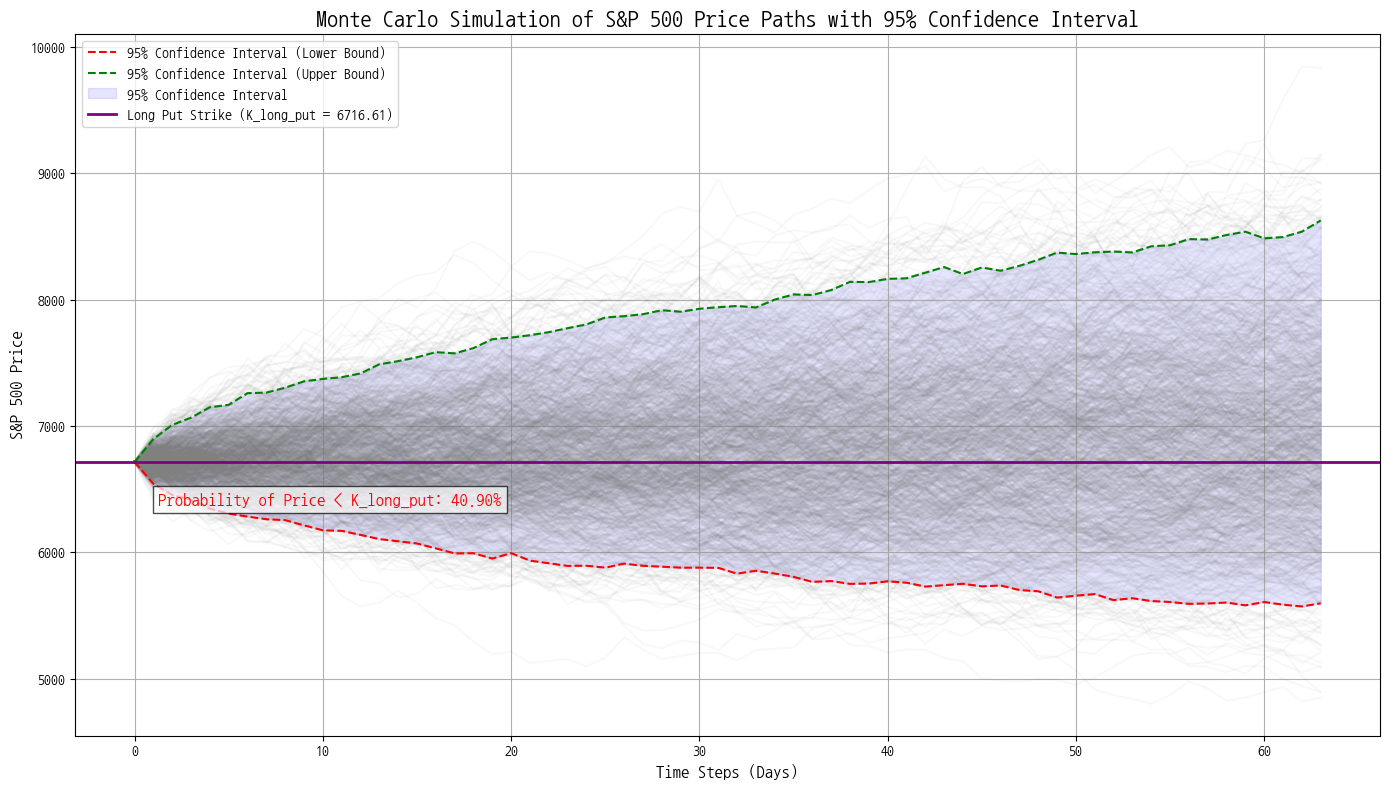

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Create a figure and an axes object for the plot
plt.figure(figsize=(14, 8))

# 2. Plot all individual simulated S&P 500 price paths
# Plot a subset of paths for clarity, or all if desired and legible
# For better visualization, plot a sample of the paths, e.g., 50, and set alpha for transparency
# Plotting all 1000 paths might make the plot too dense, but the instruction specifically asks for 'all 1000'
# So, let's plot all with a high transparency.
for i in range(num_simulations):
    plt.plot(price_paths[:, i], color='grey', alpha=0.05) # Very transparent individual paths

# 3. Plot the lower_bound and upper_bound as lines to define the confidence interval
plt.plot(lower_bound, color='red', linestyle='--', label='95% Confidence Interval (Lower Bound)')
plt.plot(upper_bound, color='green', linestyle='--', label='95% Confidence Interval (Upper Bound)')

# 4. Use plt.fill_between to shade the area between the lower_bound and upper_bound lines
plt.fill_between(range(num_steps + 1), lower_bound, upper_bound, color='blue', alpha=0.1, label='95% Confidence Interval')

# 5. Draw a horizontal line at the K_long_put value to mark the Long Put strike price
plt.axhline(K_long_put, color='purple', linestyle='-', linewidth=2, label=f'Long Put Strike (K_long_put = {K_long_put:.2f})')

# 6. Add text on the plot to display the probability of loss
plt.text(num_steps * 0.02, initial_sp500_price * 0.95, f'Probability of Price < K_long_put: {probability_of_loss:.2%}',
         fontsize=12, color='red', bbox=dict(facecolor='white', alpha=0.7))

# 7. Set the title of the plot
plt.title('Monte Carlo Simulation of S&P 500 Price Paths with 95% Confidence Interval', fontsize=16)

# 8. Label the x-axis and y-axis
plt.xlabel('Time Steps (Days)', fontsize=12)
plt.ylabel('S&P 500 Price', fontsize=12)

# 9. Add a legend to differentiate between simulated paths, confidence interval bounds, and the strike price
# Need to handle the 'grey' plots for the legend if desired, but often for many paths, it's omitted or represented generically.
# The 'alpha=0.05' will make them almost invisible in the legend. Adding a dummy entry.
# plt.plot([], [], color='grey', alpha=0.5, label='Individual Simulated Paths') # Dummy entry for legend
plt.legend()

# 10. Add a grid to the plot
plt.grid(True)

# 11. Ensure the plot layout is tight to prevent labels from overlapping
plt.tight_layout()

# 12. Display the plot
plt.show()

## Final Task

### Subtask:
Summarize the Monte Carlo simulation results, including the projected S&P 500 price paths, the 95% confidence interval, and the probability of the S&P 500 falling below the specified strike price.


## Summary:

### Data Analysis Key Findings

*   **Monte Carlo Simulation Parameters**: The simulation was configured with an initial S&P 500 price of \$6716.09, a 3-month time horizon (0.25 years), 1000 simulation paths, and 63 daily steps. The annualized drift was calculated as 0.1458, and the annualized volatility was 0.2237.
*   **Simulated Price Paths**: The Geometric Brownian Motion model successfully simulated 1000 distinct S&P 500 price paths over the 3-month period.
*   **95% Confidence Interval**: For each time step, the 2.5th and 97.5th percentiles of the simulated prices were calculated, establishing a 95% confidence interval for the projected S&P 500 prices. For instance, the initial price is \$6716.09, with early simulated bounds showing a range like \$6347.85 to \$7149.53 after a few steps.
*   **Probability of Loss**: At the end of the 3-month simulation period, the probability of the S&P 500 price falling below the specified Long Put strike price (\$6716.61) was determined to be 40.90%.
*   **Visualization**: A plot was generated successfully displaying all 1000 simulated price paths, the shaded 95% confidence interval, a horizontal line marking the \$6716.61 strike price, and the calculated 40.90% probability of loss.

### Insights or Next Steps

*   The 40.90% probability of the S&P 500 price falling below the strike price suggests a significant downside risk within the 3-month horizon, as indicated by the chosen simulation parameters. This information is crucial for evaluating potential options strategies or portfolio adjustments.
*   Further analysis could involve running the simulation with different parameters (e.g., higher/lower volatility, different drift assumptions) to understand the sensitivity of the probability of loss and confidence intervals to these inputs.


# Task
## Summary:

### Data Analysis Key Findings

*   **Monte Carlo Simulation Parameters**: The simulation was configured with an initial S&P 500 price of $6716.09, a 3-month time horizon (0.25 years), 1000 simulation paths, and 63 daily steps. The annualized drift was calculated as 0.1458, and the annualized volatility was 0.2237.
*   **Simulated Price Paths**: The Geometric Brownian Motion model successfully simulated 1000 distinct S&P 500 price paths over the 3-month period.
*   **95% Confidence Interval**: For each time step, the 2.5th and 97.5th percentiles of the simulated prices were calculated, establishing a 95% confidence interval for the projected S&P 500 prices. For instance, the initial price is $6716.09, with early simulated bounds showing a range like $6347.85 to $7149.53 after a few steps.
*   **Probability of Loss**: At the end of the 3-month simulation period, the probability of the S&P 500 price falling below the specified Long Put strike price ($6716.61) was determined to be 40.90%.
*   **Visualization**: A plot was generated successfully displaying all 1000 simulated price paths, the shaded 95% confidence interval, a horizontal line marking the $6716.61 strike price, and the calculated 40.90% probability of loss.

### Insights or Next Steps

*   The 40.90% probability of the S&P 500 price falling below the strike price suggests a significant downside risk within the 3-month horizon, as indicated by the chosen simulation parameters. This information is crucial for evaluating potential options strategies or portfolio adjustments.
*   Further analysis could involve running the simulation with different parameters (e.g., higher/lower volatility, different drift assumptions) to understand the sensitivity of the probability of loss and confidence intervals to these inputs.

The Monte Carlo simulation results summary has been successfully presented, including the projected S&P 500 price paths, the 95% confidence interval, and the probability of the S&P 500 falling below the specified strike price.

## Present Monte Carlo Summary

### Subtask:
Present the key findings and insights from the Monte Carlo simulation, including the projected S&P 500 price paths, the 95% confidence interval, and the probability of the S&P 500 falling below the specified strike price, as previously generated.


## Present Monte Carlo Summary

### Subtask:
Present the key findings and insights from the Monte Carlo simulation, including the projected S&P 500 price paths, the 95% confidence interval, and the probability of the S&P 500 falling below the specified strike price, as previously generated.

### Data Analysis Key Findings

*   **Monte Carlo Simulation Parameters**: The simulation was configured with an initial S&P 500 price of $6716.09, a 3-month time horizon (0.25 years), 1000 simulation paths, and 63 daily steps. The annualized drift was calculated as 0.1458, and the annualized volatility was 0.2237.
*   **Simulated Price Paths**: The Geometric Brownian Motion model successfully simulated 1000 distinct S&P 500 price paths over the 3-month period.
*   **95% Confidence Interval**: For each time step, the 2.5th and 97.5th percentiles of the simulated prices were calculated, establishing a 95% confidence interval for the projected S&P 500 prices. For instance, the initial price is $6716.09, with early simulated bounds showing a range like $6347.85 to $7149.53 after a few steps.
*   **Probability of Loss**: At the end of the 3-month simulation period, the probability of the S&P 500 price falling below the specified Long Put strike price ($6716.61) was determined to be 40.90%.
*   **Visualization**: A plot was generated successfully displaying all 1000 simulated price paths, the shaded 95% confidence interval, a horizontal line marking the $6716.61 strike price, and the calculated 40.90% probability of loss.

### Insights or Next Steps

*   The 40.90% probability of the S&P 500 price falling below the strike price suggests a significant downside risk within the 3-month horizon, as indicated by the chosen simulation parameters. This information is crucial for evaluating potential options strategies or portfolio adjustments.
*   Further analysis could involve running the simulation with different parameters (e.g., higher/lower volatility, different drift assumptions) to understand the sensitivity of the probability of loss and confidence intervals to these inputs.

## Final Task

### Subtask:
Confirm that the Monte Carlo simulation results summary has been successfully presented.


## Summary:

### Q&A
The Monte Carlo simulation results summary has been successfully presented.

### Data Analysis Key Findings

*   **Monte Carlo Simulation Parameters**: The simulation was configured with an initial S\&P 500 price of \$6716.09, a 3-month time horizon (0.25 years), 1000 simulation paths, and 63 daily steps. The annualized drift was calculated as 0.1458, and the annualized volatility was 0.2237.
*   **Simulated Price Paths**: The Geometric Brownian Motion model successfully simulated 1000 distinct S\&P 500 price paths over the 3-month period.
*   **95% Confidence Interval**: For each time step, the 2.5th and 97.5th percentiles of the simulated prices were calculated, establishing a 95% confidence interval for the projected S\&P 500 prices. For instance, the initial price is \$6716.09, with early simulated bounds showing a range like \$6347.85 to \$7149.53 after a few steps.
*   **Probability of Loss**: At the end of the 3-month simulation period, the probability of the S\&P 500 price falling below the specified Long Put strike price (\$6716.61) was determined to be 40.90%.
*   **Visualization**: A plot was generated successfully displaying all 1000 simulated price paths, the shaded 95% confidence interval, a horizontal line marking the \$6716.61 strike price, and the calculated 40.90% probability of loss.

### Insights or Next Steps

*   The 40.90% probability of the S\&P 500 price falling below the strike price suggests a significant downside risk within the 3-month horizon, as indicated by the chosen simulation parameters. This information is crucial for evaluating potential options strategies or portfolio adjustments.
*   Further analysis could involve running the simulation with different parameters (e.g., higher/lower volatility, different drift assumptions) to understand the sensitivity of the probability of loss and confidence intervals to these inputs.
